# Eval Analysis — Per-Env-Type Results

Analyse output from `eval_ftr.py` / `eval_ftr_rand.py` with `--output_dir`.

Each eval run produces three CSV files inside the output directory:
- **eval_summary.csv** — one row per repeat, overall aggregate metrics
- **eval_per_env.csv** — one row per (repeat × env_type), per-terrain metrics
- **eval_episodes.csv** — one row per completed episode, granular data

Multiple runs (different policies / configs) can share the same output dir and are distinguished by `eval_id`.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    "font.size":        15,
    "axes.titlesize":   18,
    "axes.labelsize":   15,
    "xtick.labelsize":  14,
    "ytick.labelsize":  15,
    "legend.fontsize":  15,
    "figure.titlesize": 18,
})

# Workspace root — notebook lives at <WS_ROOT>/notebooks/eval_analysis.ipynb
try:
    WS_ROOT = Path(__vsc_ipynb_file__).resolve().parent.parent
except NameError:
    WS_ROOT = Path.cwd().parent  # fallback when cwd is the notebooks/ dir

# ── CONFIG ────────────────────────────────────────────────────────────────────
# Paths relative to WS_ROOT (or absolute — both work).
EVAL_DIRS = [
    #"experiments/random_straight",
    #"experiments/random_range_unsynced",
    #"experiments/random_range_synced",
    #"experiments/random_best",
    "experiments/best_long",
    #"experiments/best_short",
    #"experiments/averaged",
    #"experiments/eval_top3_averaged",
    #"experiments/legacy_arch",
    #"experiments/gp_pred",
    #"experiments/optuna_247",
    "logs/eval_ftr_11055111",
    "logs/eval_ftr_11060118",
    "logs/eval_ftr_11055108",

]

# Human-readable labels for each eval_id (optional; falls back to eval_id string).
EVAL_LABELS: dict[str, str] = {
    "rand_best":            "Tuned baseline",
    "rand_range_synced":    "Random symmetric",
    "rand_range_unsynced":  "Random unsymmetric",
    "rand_straight":        "Forward only",
    "best_long":            "Ours",
    "best":                 "Trial 160",
    "avaraged_local":       "Averaged",
    "david":                "Spring-based",
    "legacy_architecture":  "Spring architecture",
    "optuna_51":"Trial 51",
    "optuna_112":"Trial 112",
    "optuna_225":"Trial 225",
    "optuna_230":"Trial 230",
}

# Colour palette for multi-eval comparison (auto-cycles if more evals than colours)
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

# Short, presentation-friendly env-type names (used for x-tick labels)
ENV_NAME_SHORT: dict[str, str] = {
    "raised_platform":     "Raised plat.",
    "lowered_platform":    "Lowered plat.",
    "rails":               "Rails",
    "diag_rail":           "Diag. rail",
    "asymmetric_platform": "Asym. plat.",
    "diag_mound":          "Diag. mound",
    "trenches":            "Trenches",
    "cobblestone":         "Cobblestone",
    "steps_lowered":       "Steps down",
    "steps_raised":        "Steps up",
    "large_blocks":        "Lg. blocks",
    "medium_blocks":       "Md. blocks",
    "diag_blocks":         "Diag. blocks",
    "diag_platform":       "Diag. plat.",
    "large_steps":         "Lg. steps",
    "flat_patch":          "Flat",
}

def env_short(name: str) -> str:
    """Map a full env_type_name to its short, presentation-friendly label."""
    return ENV_NAME_SHORT.get(name, name)
# ─────────────────────────────────────────────────────────────────────────────

## 1  Load data

In [16]:
def _resolve(d: str | Path) -> Path:
    p = Path(d)
    return p if p.is_absolute() else WS_ROOT / p

def _load(name: str) -> pd.DataFrame:
    frames = []
    for d in EVAL_DIRS:
        p = _resolve(d) / name
        if p.exists():
            frames.append(pd.read_csv(p))
        else:
            print(f"[warn] {p} not found — skipping")
    if not frames:
        raise FileNotFoundError(f"No {name} found in {EVAL_DIRS}")
    df = pd.concat(frames, ignore_index=True)
    df["label"] = df["eval_id"].map(lambda eid: EVAL_LABELS.get(eid, eid))
    return df

summary_df  = _load("eval_summary.csv")
per_env_df  = _load("eval_per_env.csv")
episodes_df = _load("eval_episodes.csv")

eval_ids = summary_df["eval_id"].unique().tolist()
print(f"Loaded {len(eval_ids)} eval run(s):")
for eid in eval_ids:
    lbl = EVAL_LABELS.get(eid, eid)
    n_rep = summary_df[summary_df.eval_id == eid].shape[0]
    n_eps = episodes_df[episodes_df.eval_id == eid].shape[0]
    print(f"  {lbl}  — {n_rep} repeat(s), {n_eps} episodes")

# Stable ordering (success rate descending) and per-label colors used by all plots.
_mean_sr   = summary_df.groupby("eval_id")["success_rate"].mean()
EVAL_ORDER = sorted(eval_ids, key=lambda eid: _mean_sr.get(eid, 0), reverse=True)
LABEL_COLOR = {EVAL_LABELS.get(eid, eid): PALETTE[i % len(PALETTE)]
               for i, eid in enumerate(EVAL_ORDER)}

Loaded 4 eval run(s):
  Ours  — 30 repeat(s), 27894 episodes
  long_run  — 30 repeat(s), 33734 episodes
  safe  — 27 repeat(s), 38186 episodes
  highest_shock_tmp  — 30 repeat(s), 45574 episodes


## 2  Overall metrics (aggregate across all env types)

,success_rate,failure_rate,explosion_rate,mean_step_reward,truncated_rate
label,,,,,
highest_shock_tmp,0.8384,0.1583,0.0,-0.0010,0.0032
safe,0.8362,0.1534,0.0,-0.0005,0.0104
Ours,0.7942,0.1358,0.0,-0.0035,0.0699
long_run,0.7371,0.2309,0.0,0.0006,0.0312


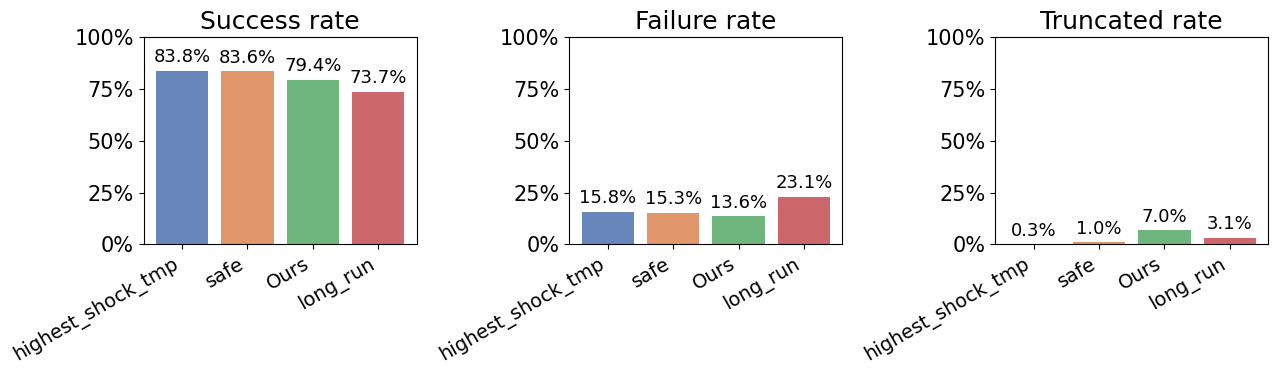

In [17]:
agg = summary_df.groupby("label")[["success_rate","failure_rate","explosion_rate","mean_step_reward"]].mean()

# Compute truncated rate from episode-level data (not in summary CSV)
trunc_rate = (
    episodes_df.groupby("label")
    .apply(lambda g: (g["outcome"] == "truncated").mean())
    .rename("truncated_rate")
)
agg = agg.join(trunc_rate)

# Reindex to EVAL_ORDER (success rate descending, stable across all plots)
ordered_labels = [EVAL_LABELS.get(eid, eid) for eid in EVAL_ORDER if EVAL_LABELS.get(eid, eid) in agg.index]
agg = agg.reindex(ordered_labels)
display(agg.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes,
    ["success_rate", "failure_rate", "truncated_rate"],
    ["Success rate", "Failure rate", "Truncated rate"]):
    vals = [agg.loc[lbl, col] for lbl in agg.index]
    colors = [LABEL_COLOR[lbl] for lbl in agg.index]
    errs = []
    for lbl in agg.index:
        if col == "truncated_rate":
            per_rep = (
                episodes_df[episodes_df.label == lbl]
                .groupby("repeat")
                .apply(lambda g: (g["outcome"] == "truncated").mean())
                .values
            )
            errs.append(per_rep.std() / np.sqrt(len(per_rep)) if len(per_rep) > 1 else 0)
        else:
            v = summary_df[summary_df.label == lbl][col].values
            errs.append(v.std() / np.sqrt(len(v)) if len(v) > 1 else 0)
    bars = ax.bar(agg.index, vals, capsize=5, color=colors, alpha=0.85)
    for bar, val, err in zip(bars, vals, errs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + err + 0.02,
                f"{val:.1%}", ha="center", va="bottom", fontsize=13)
    ax.set_title(title, fontsize=18)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", rotation=30)
    for label in ax.get_xticklabels():
        label.set_ha("right")
plt.tight_layout()
plt.show()

## 3  Per-env-type success / failure  (with 95 % CI from bootstrapped repeats)

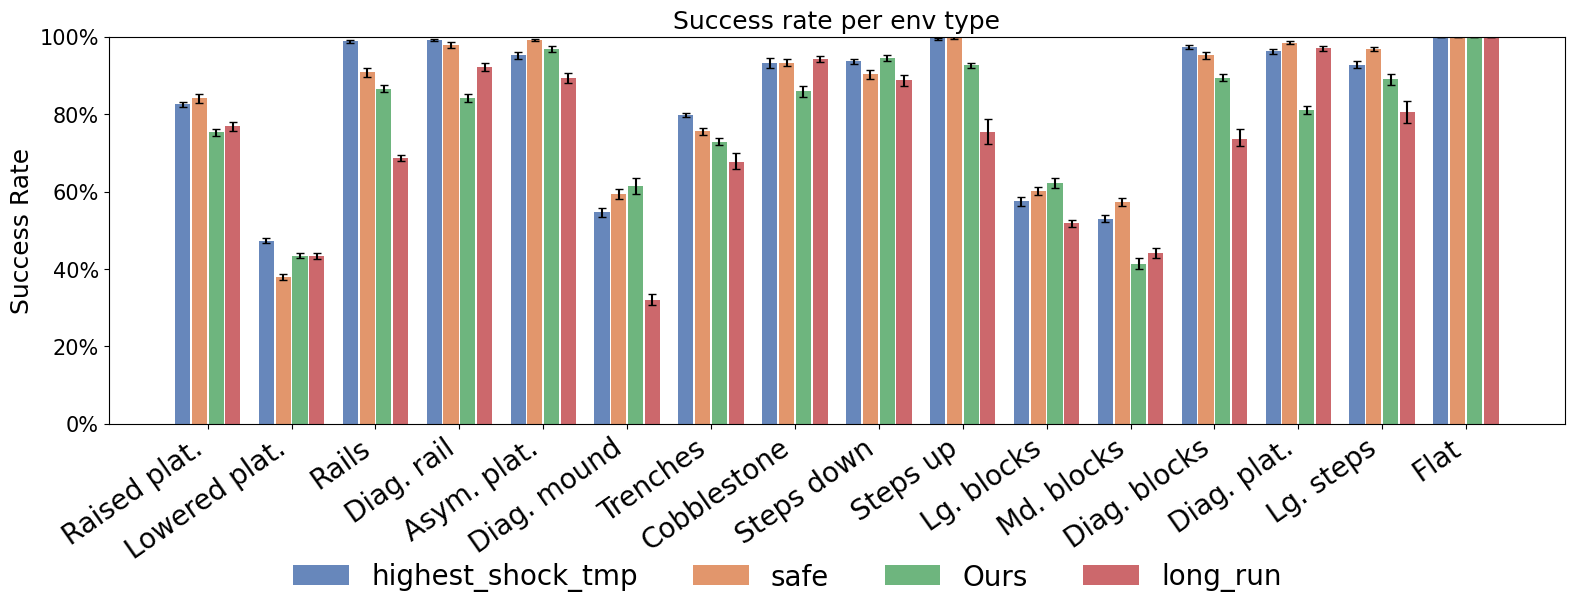

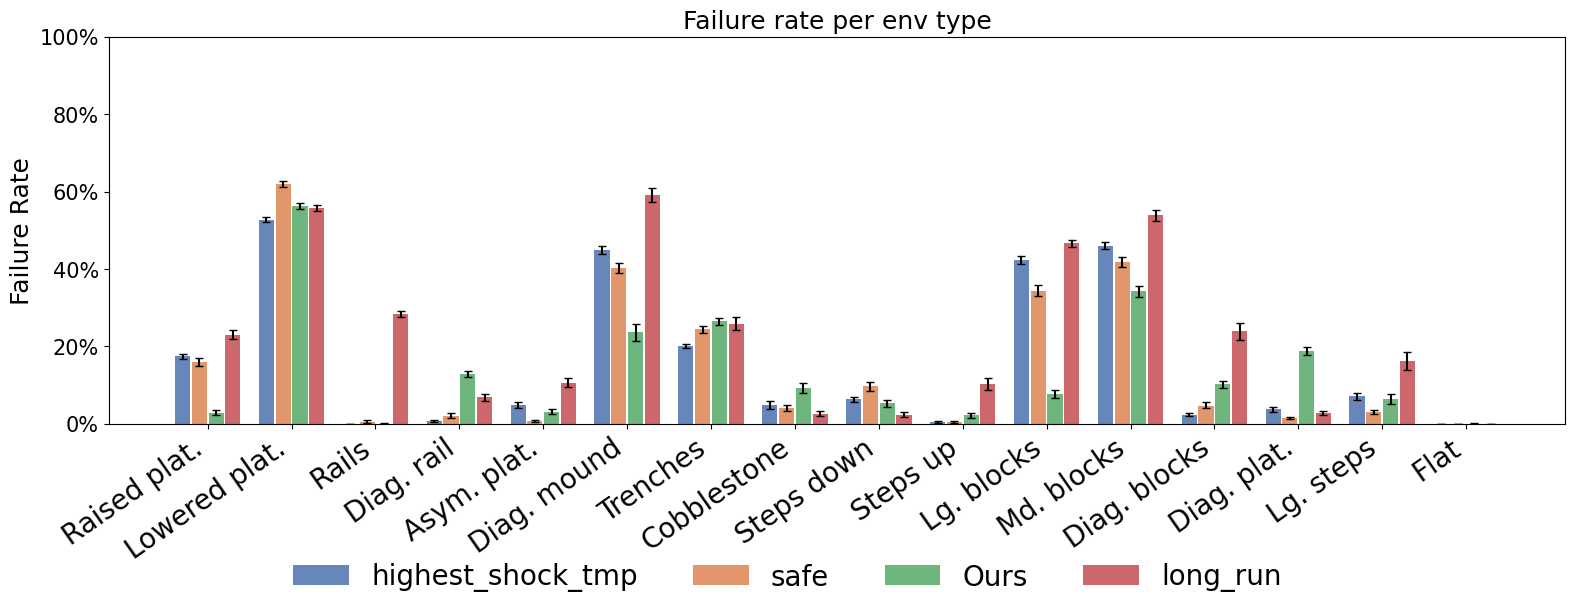

In [18]:
def bootstrap_ci(values: np.ndarray, n_boot: int = 2000, alpha: float = 0.05) -> tuple[float, float]:
    """Return (lo, hi) bootstrap confidence interval for the mean."""
    if len(values) < 2:
        return (0.0, 0.0)
    boots = np.random.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    return float(np.percentile(boots, 100*alpha/2)), float(np.percentile(boots, 100*(1-alpha/2)))

for metric, title in [("success_rate", "Success rate per env type"),
                       ("failure_rate", "Failure rate per env type")]:
    env_order = sorted(per_env_df["env_type_idx"].unique())
    env_names = per_env_df.drop_duplicates("env_type_idx").set_index("env_type_idx")["env_type_name"]
    x = np.arange(len(env_order))
    n_evals = len(EVAL_ORDER)
    width = 0.8 / max(n_evals, 1)

    fig, ax = plt.subplots(figsize=(max(12, len(env_order)), 6))
    handles, labels_legend = [], []
    for ei, eid in enumerate(EVAL_ORDER):
        lbl = EVAL_LABELS.get(eid, eid)
        sub = per_env_df[per_env_df.eval_id == eid]
        means, lo_errs, hi_errs = [], [], []
        for idx in env_order:
            vals = sub[sub.env_type_idx == idx][metric].dropna().values
            if len(vals) == 0:
                means.append(np.nan); lo_errs.append(0); hi_errs.append(0)
            else:
                m = vals.mean()
                lo, hi = bootstrap_ci(vals)
                means.append(m); lo_errs.append(m - lo); hi_errs.append(hi - m)
        offset = (ei - n_evals / 2 + 0.5) * width
        bars = ax.bar(x + offset, means, width=width * 0.9,
               yerr=[lo_errs, hi_errs], capsize=3,
               color=LABEL_COLOR[lbl], alpha=0.85, label=lbl)
        handles.append(bars)
        labels_legend.append(lbl)

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([env_short(env_names.get(i, str(i))) for i in env_order], rotation=35, ha="right", fontsize=20)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylabel(metric.replace("_", " ").title(),fontsize=18)
    fig.legend(handles, labels_legend, loc="lower center",
               ncol=n_evals, bbox_to_anchor=(0.5, -0.05), frameon=False,fontsize=20)
    plt.tight_layout()
    plt.savefig(fname=f"images/{metric}_perenv.svg",format="svg",bbox_inches="tight")
    plt.show()

## 4  Per-env-type reward (box plots from episode data)

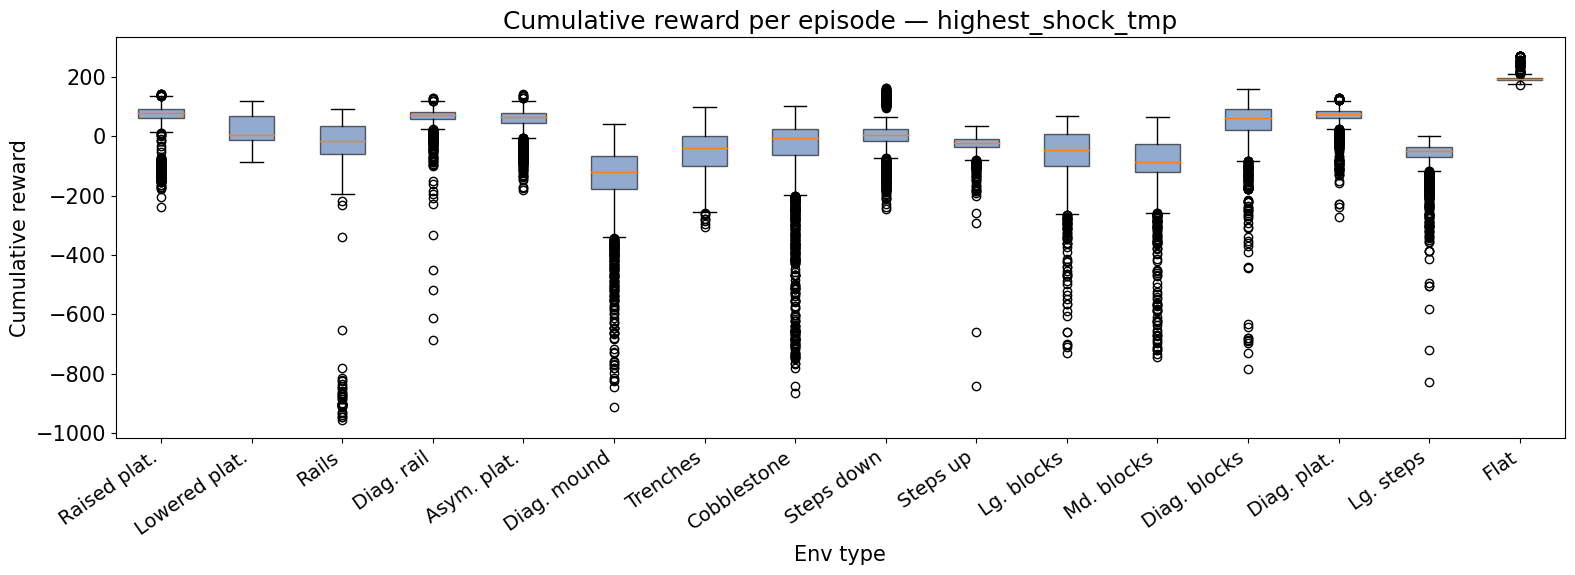

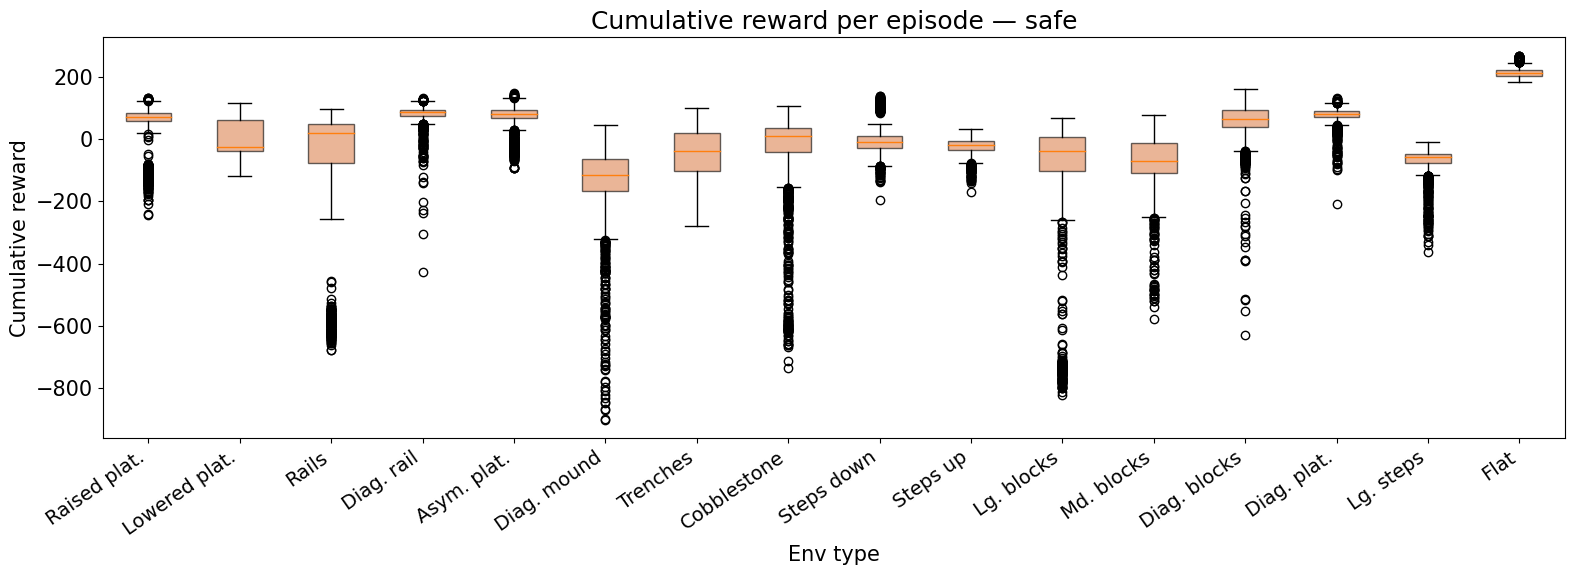

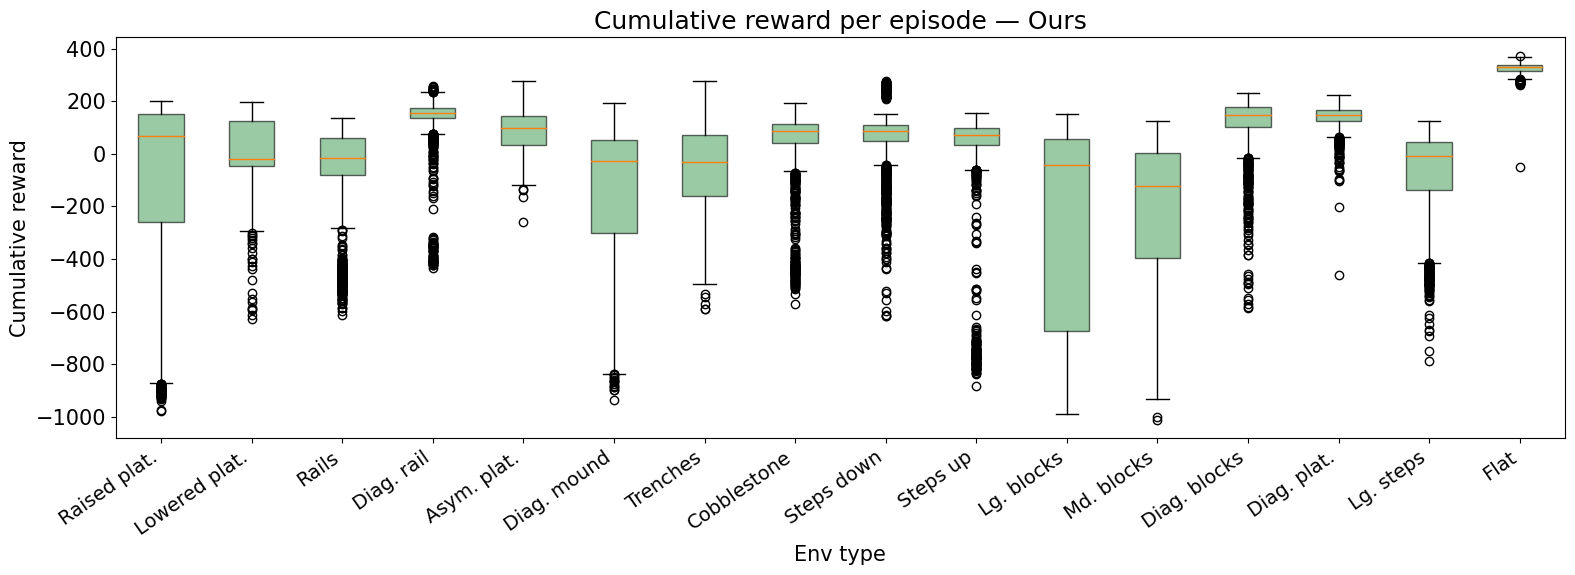

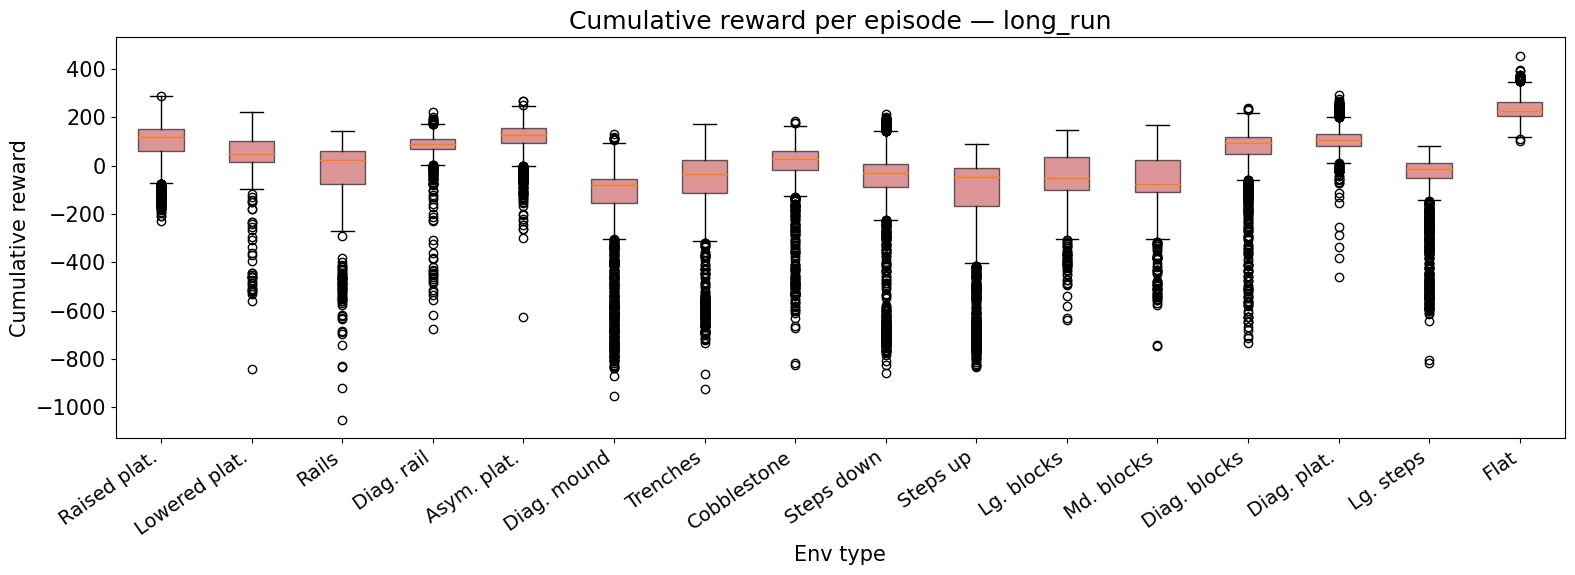

In [19]:
env_order = sorted(episodes_df["env_type_idx"].unique())
env_name_map = episodes_df.drop_duplicates("env_type_idx").set_index("env_type_idx")["env_type_name"].to_dict()

for eid in EVAL_ORDER:
    lbl = EVAL_LABELS.get(eid, eid)
    sub = episodes_df[episodes_df.eval_id == eid]
    data = [sub[sub.env_type_idx == idx]["cumulative_reward"].dropna().values for idx in env_order]
    fig, ax = plt.subplots(figsize=(max(12, len(env_order)), 6))
    ax.boxplot(data, labels=[env_short(env_name_map.get(i, str(i))) for i in env_order],
               patch_artist=True,
               boxprops=dict(facecolor=LABEL_COLOR[lbl], alpha=0.6))
    ax.set_title(f"Cumulative reward per episode — {lbl}")
    ax.set_xlabel("Env type")
    ax.set_ylabel("Cumulative reward")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

## 5  Shock analysis

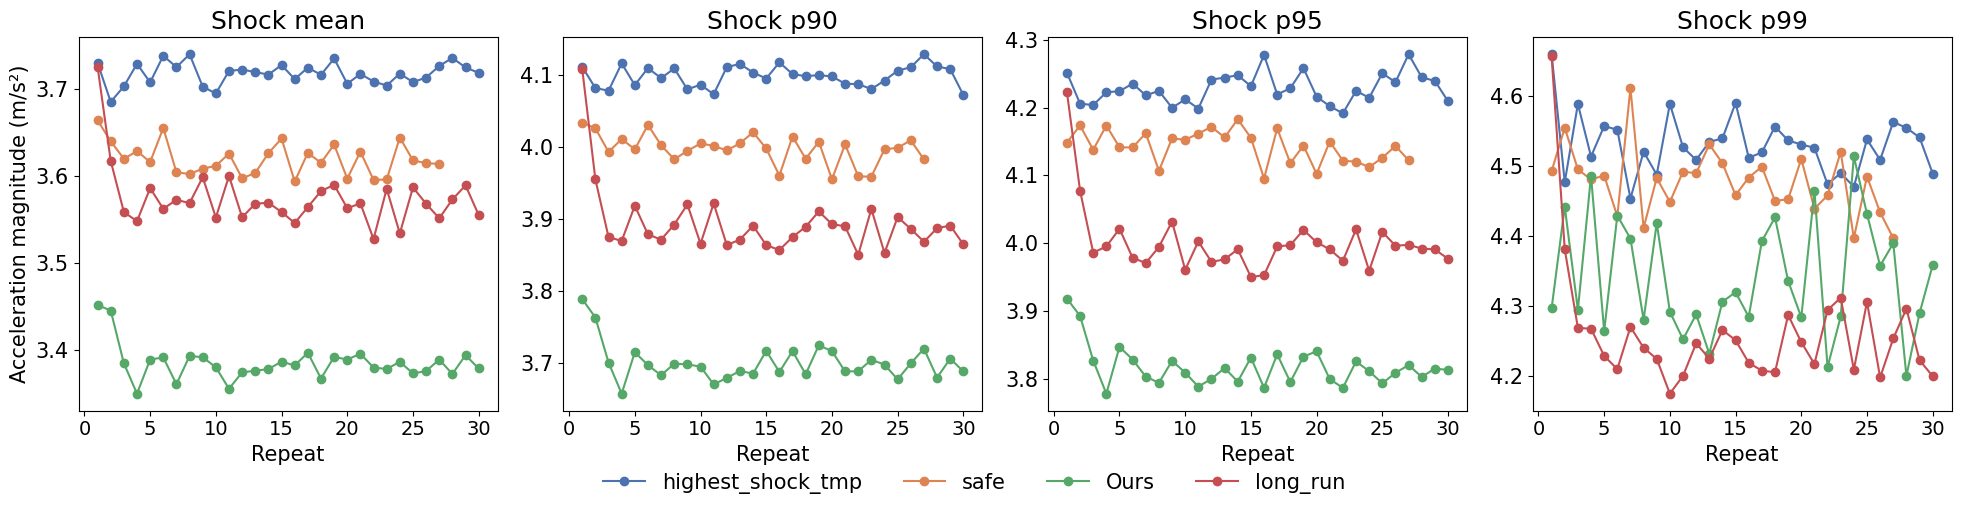

,shock_mean,shock_p90,shock_p95,shock_p99
label,,,,
Ours,3.3858,3.7002,3.8171,4.3409
highest_shock_tmp,3.7175,4.0982,4.2286,4.5303
long_run,3.5742,3.8930,4.0003,4.2597
safe,3.6195,3.9971,4.1424,4.4776


In [20]:
shock_cols = ["shock_mean", "shock_p90", "shock_p95", "shock_p99"]
shock_present = [c for c in shock_cols if c in summary_df.columns and summary_df[c].notna().any()]

if not shock_present:
    print("No shock data in eval_summary.csv — run eval with shock reward enabled.")
else:
    fig, axes = plt.subplots(1, len(shock_present), figsize=(5 * len(shock_present), 5))
    if len(shock_present) == 1:
        axes = [axes]
    handles, labels_legend = [], []
    for ax, col in zip(axes, shock_present):
        for eid in EVAL_ORDER:
            lbl = EVAL_LABELS.get(eid, eid)
            sub = summary_df[summary_df.eval_id == eid].sort_values("repeat")
            line, = ax.plot(sub["repeat"], sub[col], marker="o",
                            color=LABEL_COLOR[lbl], label=lbl)
            if lbl not in labels_legend:
                handles.append(line)
                labels_legend.append(lbl)
        ax.set_title(col.replace("_", " ").replace("s", "S"))
        ax.set_xlabel("Repeat")
    axes[0].set_ylabel("Acceleration magnitude (m/s²)")
    fig.legend(handles, labels_legend, loc="lower center",
               ncol=len(labels_legend), bbox_to_anchor=(0.5, -0.05), frameon=False)
    plt.tight_layout()
    plt.savefig(fname=f"images/shock_comp.svg",format="svg",bbox_inches="tight")
    plt.show()

    # Summary table
    display(summary_df.groupby("label")[shock_present].mean().round(4))

## 6  Flipper posture per env type

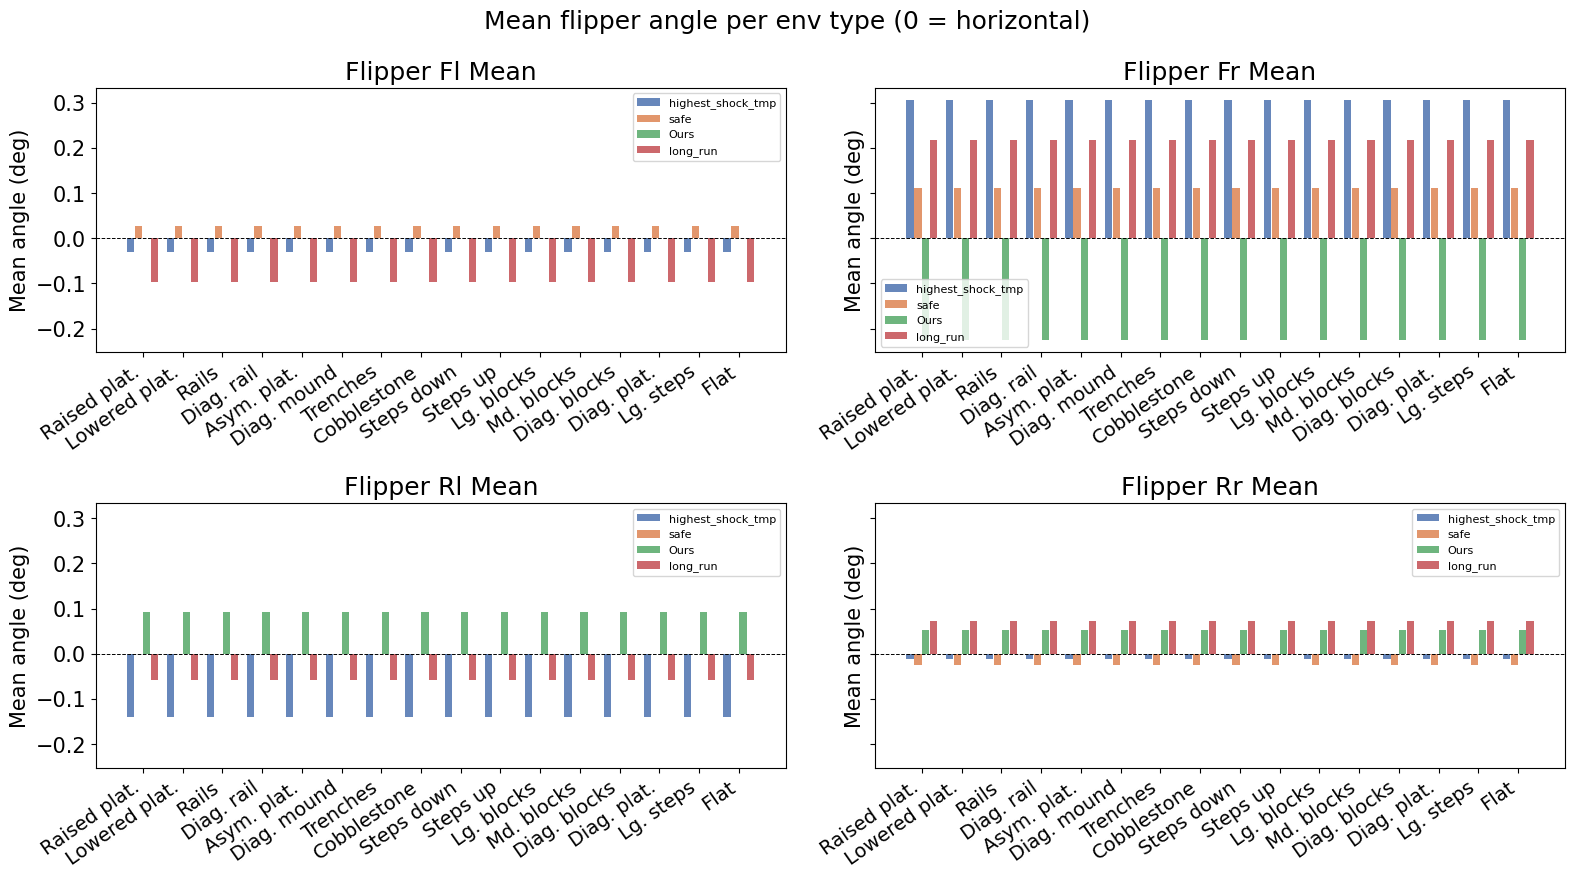

In [21]:
flipper_cols = ["flipper_fl_mean", "flipper_fr_mean", "flipper_rl_mean", "flipper_rr_mean"]
flipper_present = [c for c in flipper_cols if c in per_env_df.columns and per_env_df[c].notna().any()]

if not flipper_present:
    print("No flipper posture data in eval_per_env.csv.")
else:
    env_order = sorted(per_env_df["env_type_idx"].unique())
    env_name_map = per_env_df.drop_duplicates("env_type_idx").set_index("env_type_idx")["env_type_name"].to_dict()
    x = np.arange(len(env_order))
    labels_x = [env_short(env_name_map.get(i, str(i))) for i in env_order]
    n_evals = len(EVAL_ORDER)
    width = 0.8 / max(n_evals, 1)

    fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharey=True)
    for ax, col in zip(axes.flat, flipper_cols):
        for ei, eid in enumerate(EVAL_ORDER):
            lbl = EVAL_LABELS.get(eid, eid)
            sub = per_env_df[per_env_df.eval_id == eid].groupby("env_type_idx")[col].mean()
            vals = [sub.get(idx, np.nan) for idx in env_order]
            offset = (ei - n_evals / 2 + 0.5) * width
            ax.bar(x + offset, np.rad2deg(vals), width=width * 0.9,
                   color=LABEL_COLOR[lbl], alpha=0.85, label=lbl)
        ax.set_title(col.replace("_", " ").title())
        ax.set_xticks(x)
        ax.set_xticklabels(labels_x, rotation=35, ha="right")
        ax.set_ylabel("Mean angle (deg)")
        ax.axhline(0, color="k", linewidth=0.7, linestyle="--")
        ax.legend(fontsize=8)
    plt.suptitle("Mean flipper angle per env type (0 = horizontal)")
    plt.tight_layout()
    plt.show()

## 7  Terrain heatmap — success rate on cur_mixed grid

env types 0–14 are rows in the cur_mixed terrain (Y ≈ 23.3 … −21.5), env type 15 is the flat patch.

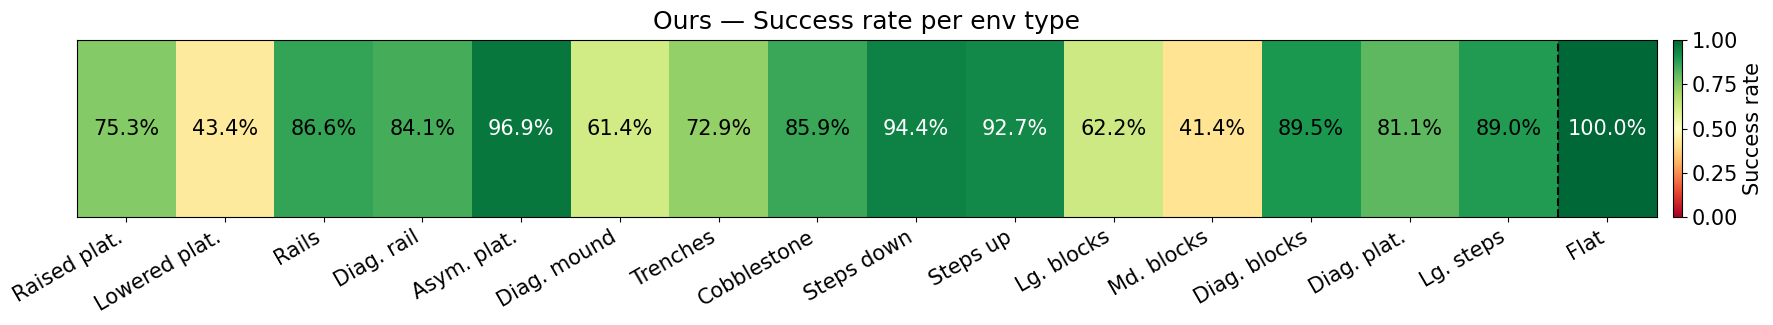

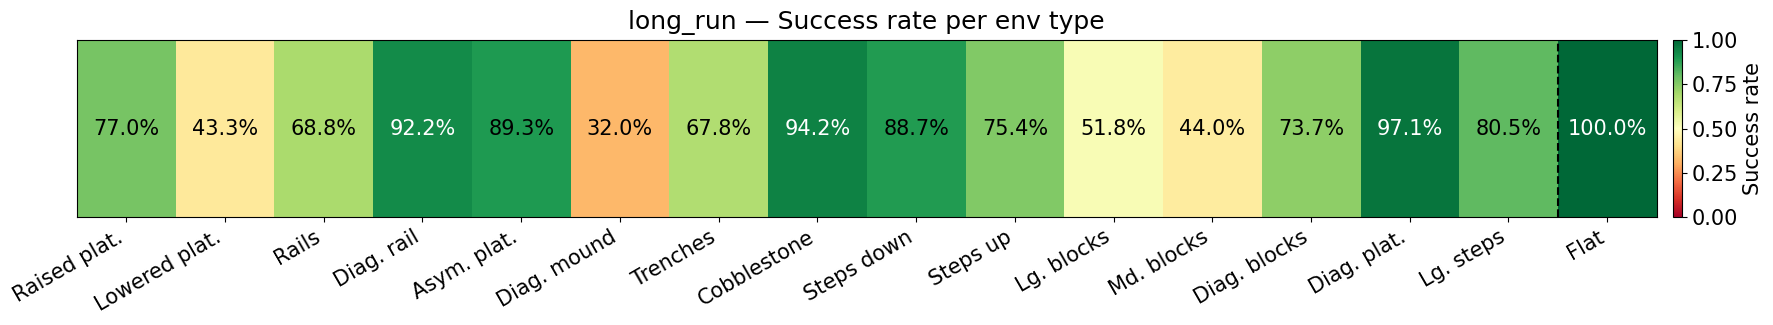

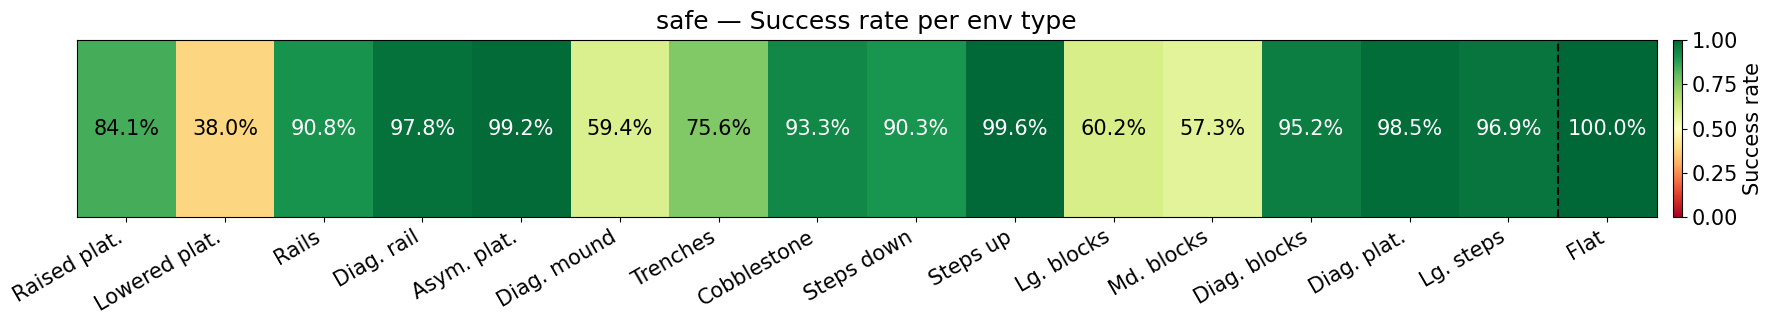

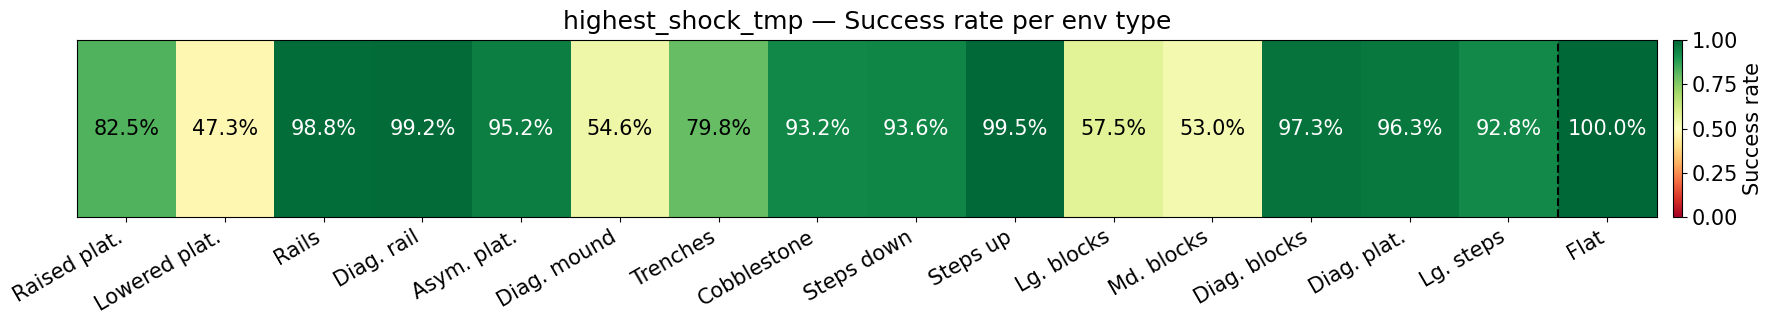

In [22]:
# Y coordinates of env types 0-14 from cur_mixed birth JSON
ENV_Y_COORDS = [23.3, 20.1, 16.9, 13.7, 10.5, 7.3, 4.1, 0.9, -2.3, -5.5, -8.7, -11.9, -15.1, -18.3, -21.5]

for eid in eval_ids:
    lbl = EVAL_LABELS.get(eid, eid)
    sub = per_env_df[per_env_df.eval_id == eid]
    sr = sub.groupby("env_type_idx")["success_rate"].mean()
    env_name_map = sub.drop_duplicates("env_type_idx").set_index("env_type_idx")["env_type_name"].to_dict()

    # 1-row × 16-col grid: env types run left→right
    grid = np.full((1, 16), np.nan)
    for idx in range(16):
        if idx in sr.index:
            grid[0, idx] = sr[idx]

    xlabels = [env_short(env_name_map.get(i, f'env_{i:02d}')) for i in range(15)]
    xlabels.append(env_short(env_name_map.get(15, 'flat_patch')))

    fig, ax = plt.subplots(figsize=(18, 3.5))
    im = ax.imshow(grid, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1, interpolation="nearest")

    ax.set_xticks(range(16))
    ax.set_xticklabels(xlabels, fontsize=15, rotation=30, ha="right")
    ax.set_yticks([])

    # Separator line between terrain types and flat patch
    ax.axvline(14.5, color="black", linewidth=1.5, linestyle="--")

    ax.set_title(f"{lbl} — Success rate per env type", pad=8, fontsize=18)

    # Value annotations
    for i in range(16):
        val = grid[0, i]
        if not np.isnan(val):
            ax.text(i, 0, f"{val:.1%}", ha="center", va="center", fontsize=15,
                    color="black" if 0.1 < val < 0.9 else "white")

    cbar = plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01, label="Success rate")
    cbar.ax.tick_params(labelsize=15)        # tick numbers (0, 0.5, 1)
    cbar.set_label("Success rate", size=15)  # axis label
    plt.tight_layout()
    plt.show()

## 7b  Spot heatmap — success rate on the full 16×10 spawn grid

Each cell is one unique birth position: rows = env type (0-15), columns = depth column (0-9, closer → farther from origin).
env type 15 (flat_patch) is separated by a dashed line.

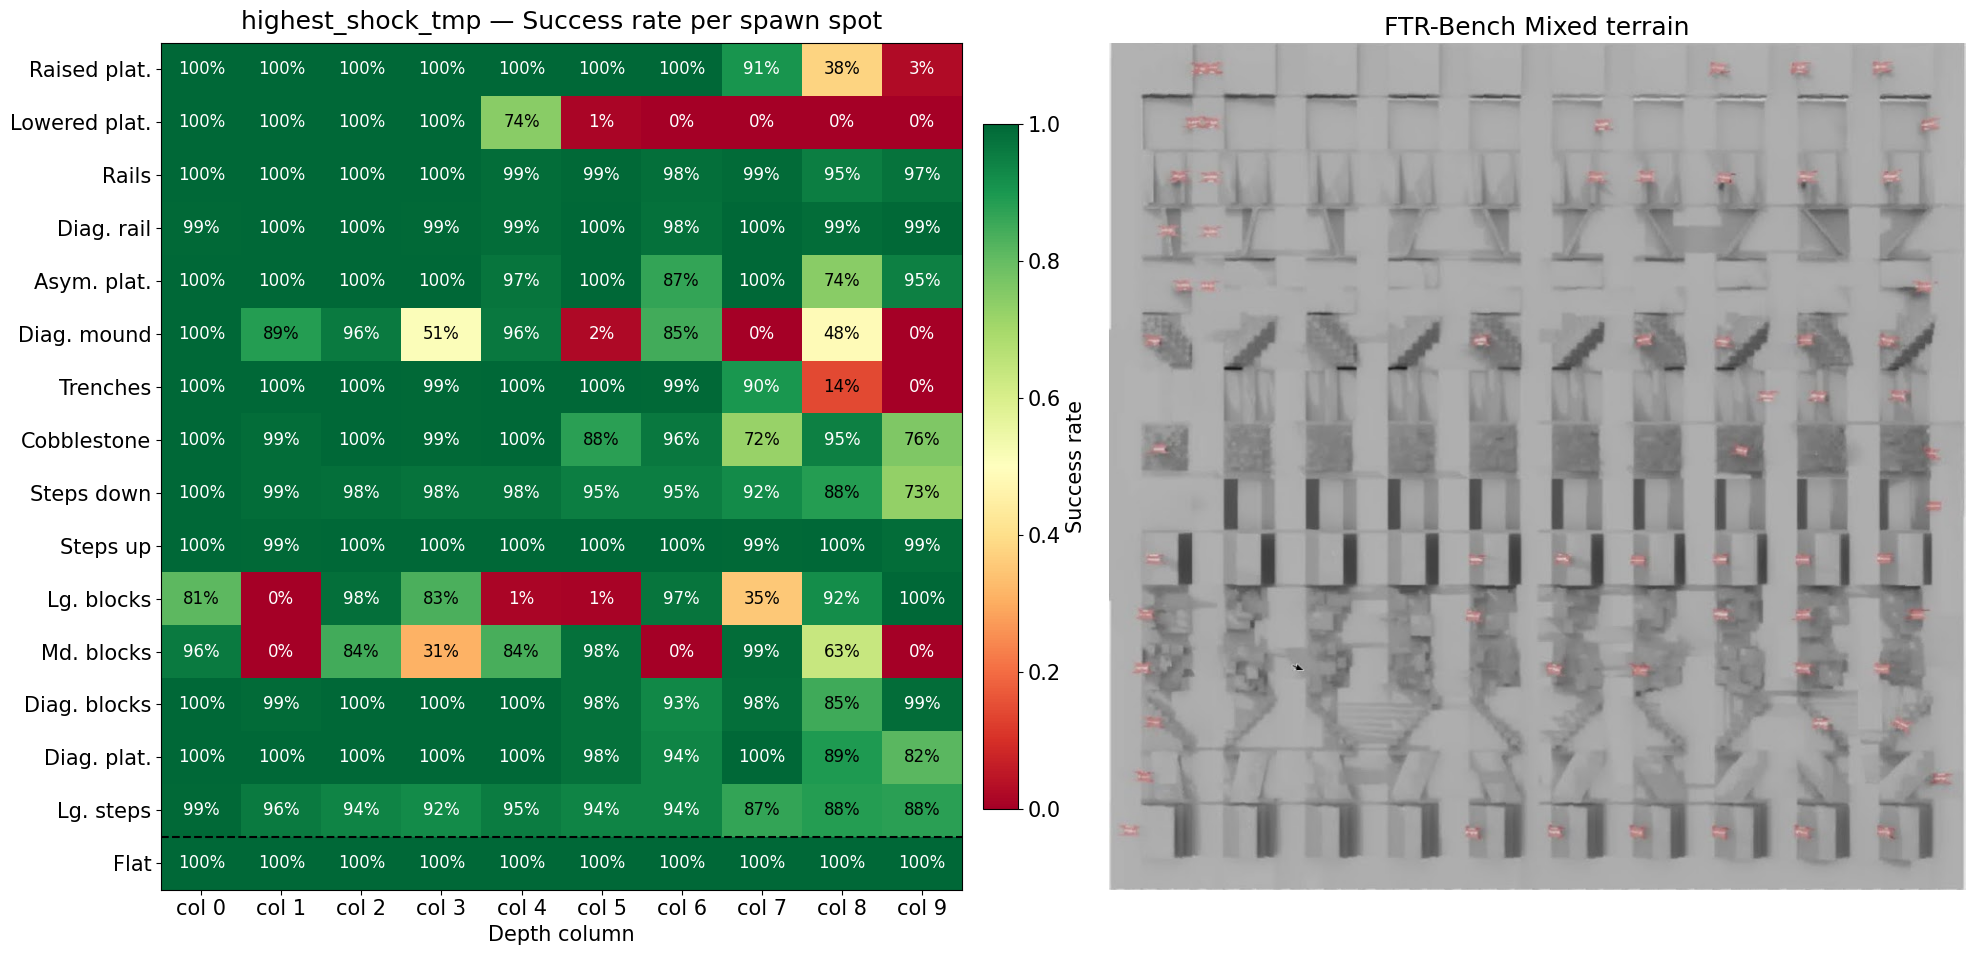

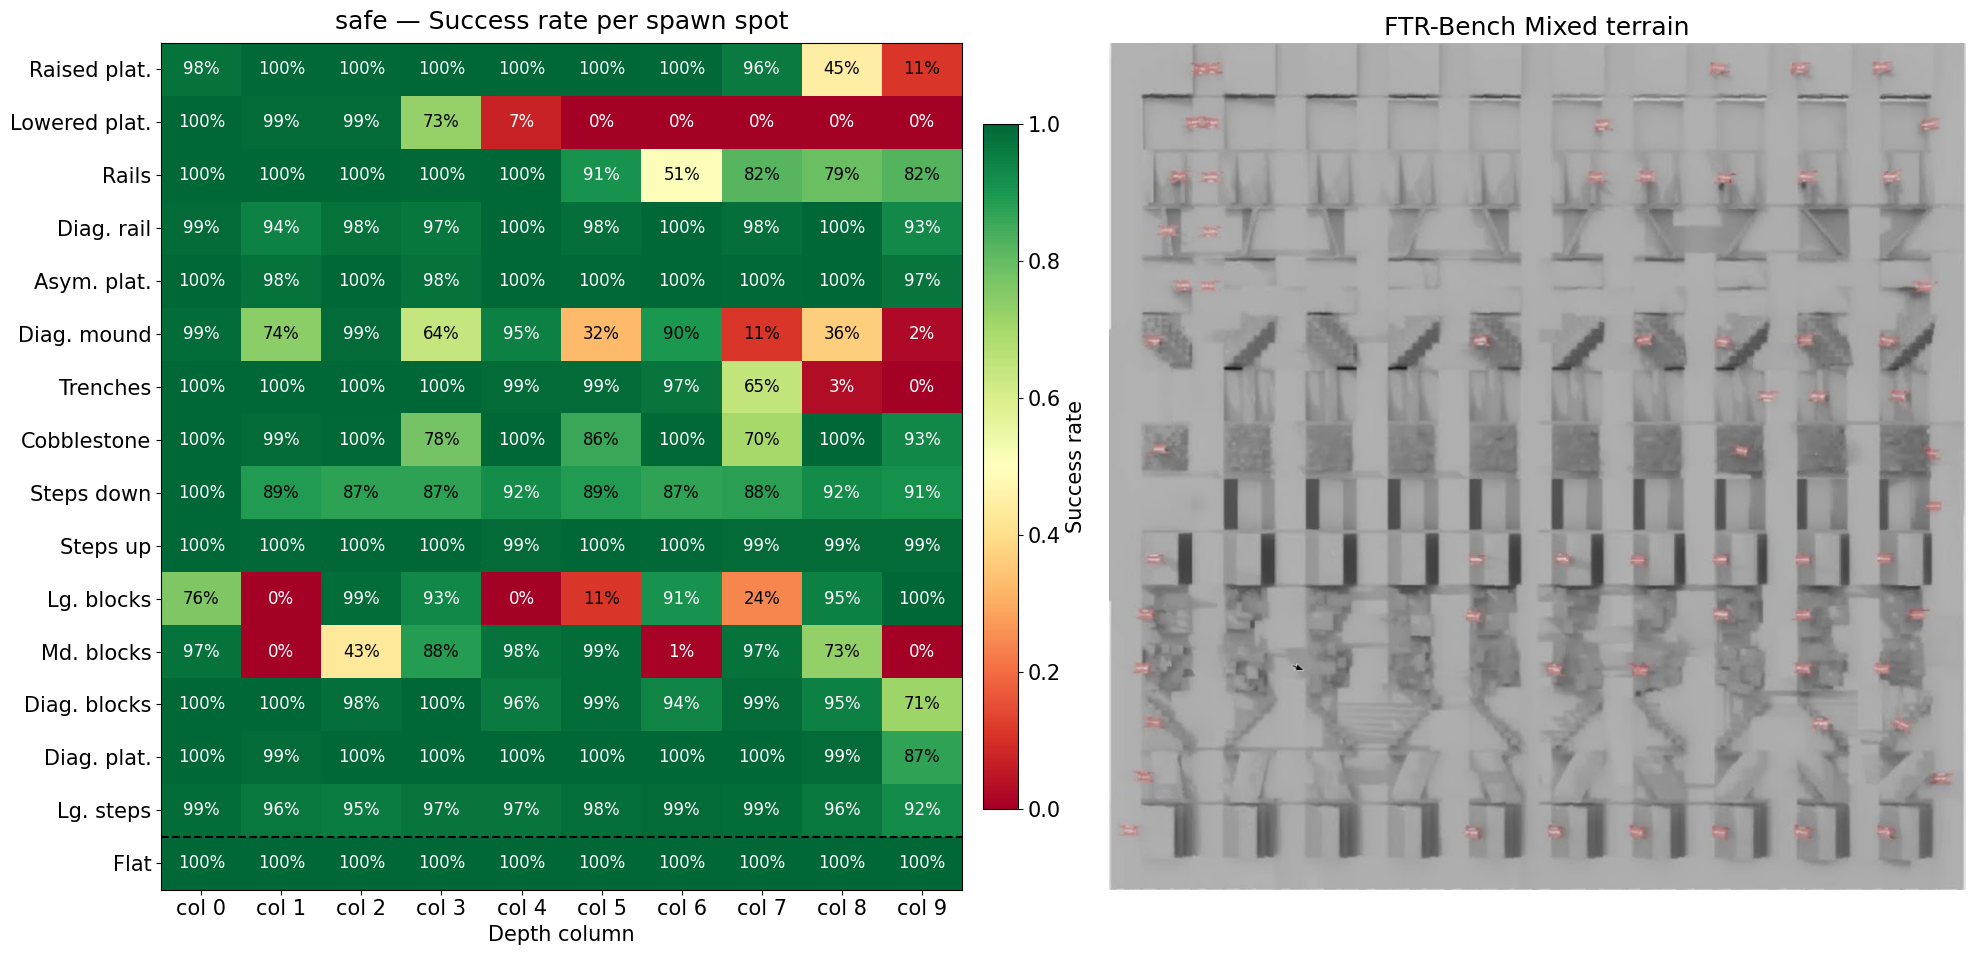

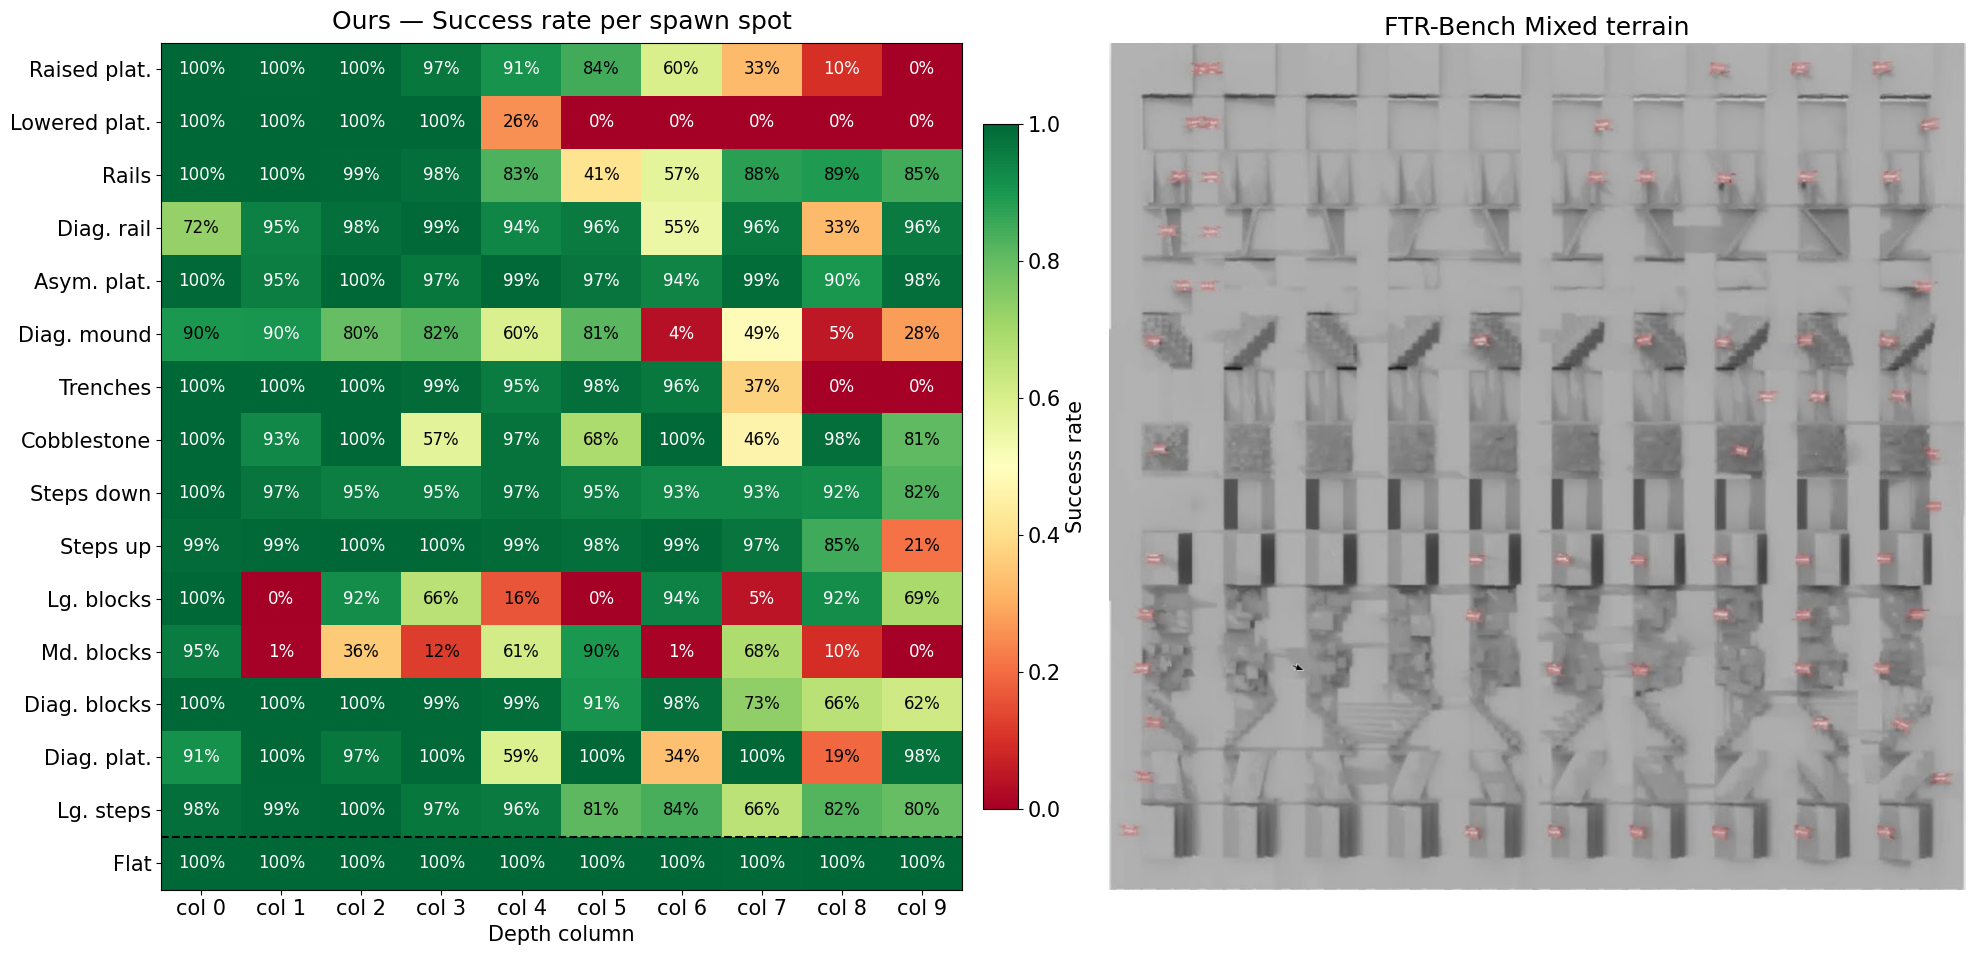

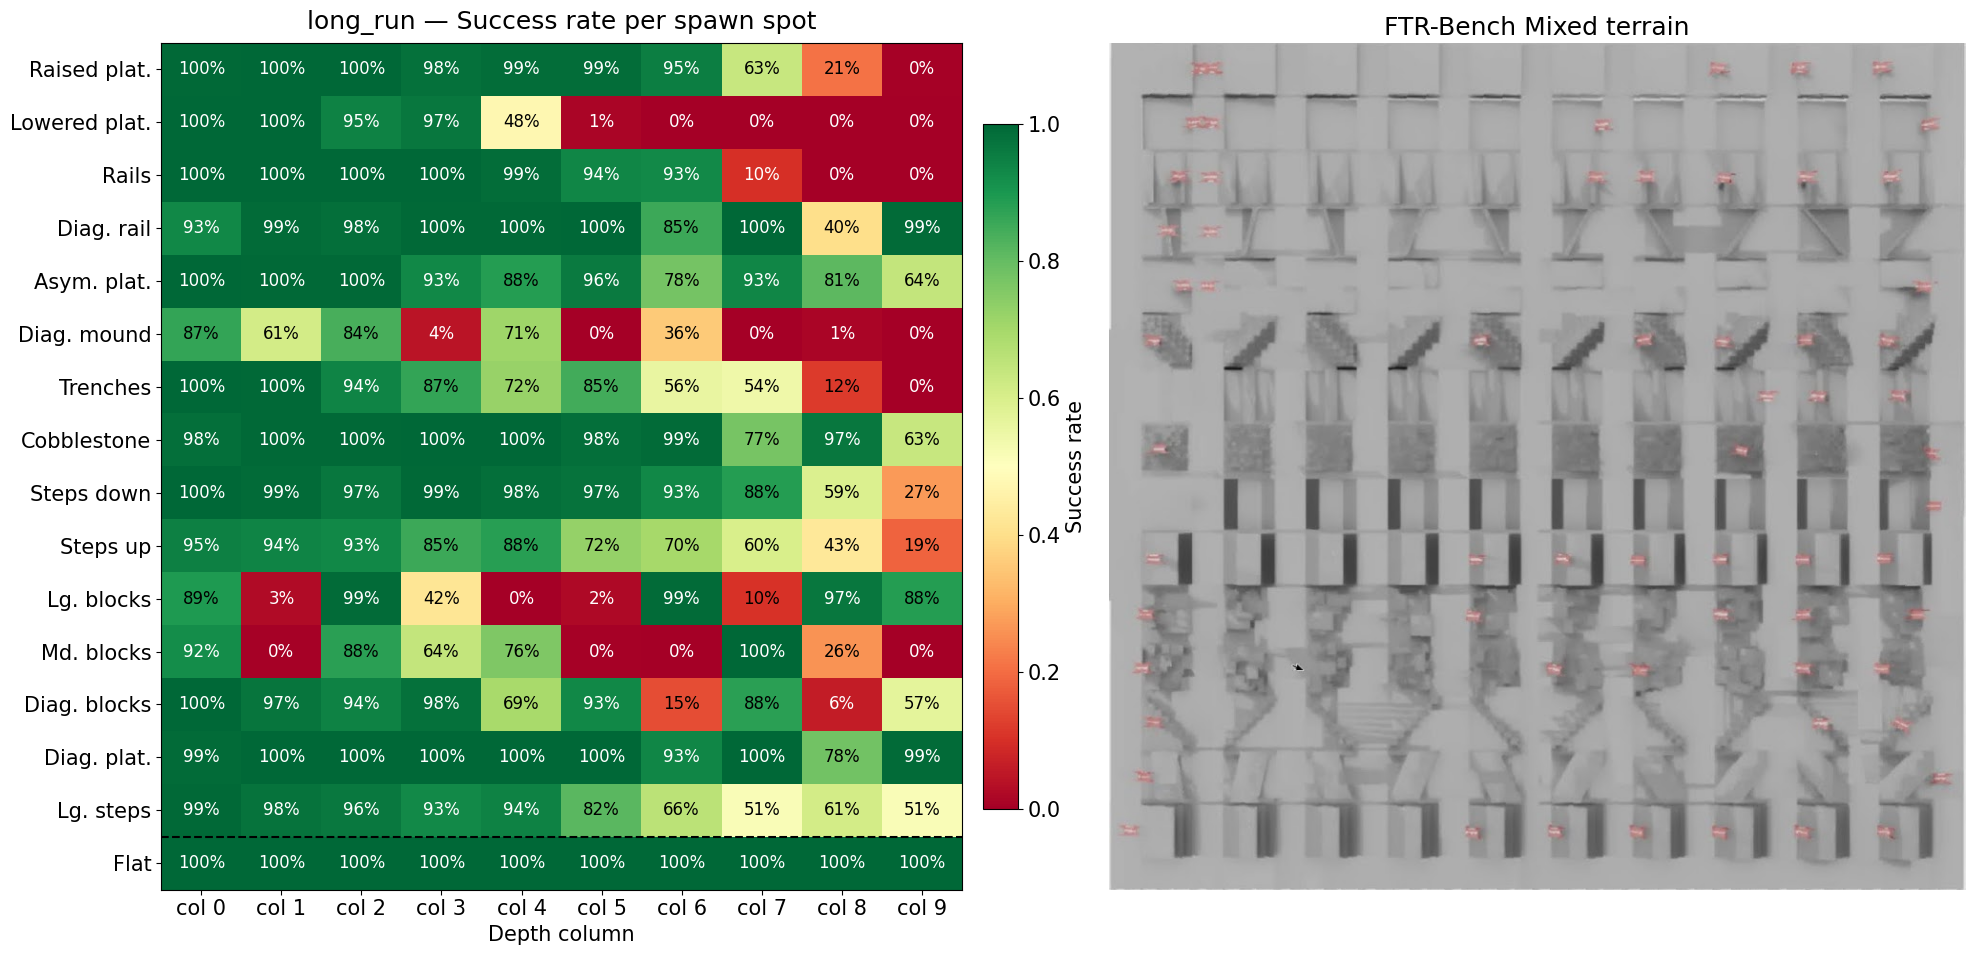

In [23]:
import matplotlib.image as mpimg

def _load_per_spot() -> pd.DataFrame | None:
    frames = []
    for d in EVAL_DIRS:
        p = _resolve(d) / "eval_per_spot.csv"
        if p.exists():
            frames.append(pd.read_csv(p))
        else:
            print(f"[warn] {p} not found — skipping (run eval to generate eval_per_spot.csv)")
    if not frames:
        return None
    df = pd.concat(frames, ignore_index=True)
    df["label"] = df["eval_id"].map(lambda eid: EVAL_LABELS.get(eid, eid))
    return df

per_spot_df = _load_per_spot()

_CUR_MIXED_IMG = next(
    (p for p in [
        WS_ROOT / "images/terrains/cur_mixed.jpg",
        WS_ROOT / "images/terrains/cur_mixed.png",
    ] if p.exists()),
    None,
)

NUM_ENV_TYPES = 16
NUM_DEPTH_COLS = 10
ENV_NAMES = [env_short(n) for n in (
    "raised_platform", "lowered_platform", "rails", "diag_rail",
    "asymmetric_platform", "diag_mound", "trenches", "cobblestone",
    "steps_lowered", "steps_raised", "large_blocks", "medium_blocks",
    "diag_blocks", "diag_platform", "large_steps", "flat_patch",
)]

def _spot_grid(df, eid):
    avg = df[df.eval_id == eid].groupby(["env_type_idx", "depth_col"])["success_rate"].mean()
    grid = np.full((NUM_ENV_TYPES, NUM_DEPTH_COLS), np.nan)
    for (env_idx, col), val in avg.items():
        if env_idx < NUM_ENV_TYPES and col < NUM_DEPTH_COLS:
            grid[env_idx, col] = val
    return grid

def _annotate_spot(ax, grid, fmt=".0%"):
    for ei in range(grid.shape[0]):
        for c in range(grid.shape[1]):
            val = grid[ei, c]
            if not np.isnan(val):
                txt = f"{val:{fmt}}" if fmt != "+.0%" else f"{val:+.0%}"
                color = "black" if 0.1 < val < 0.9 else "white"
                ax.text(c, ei, txt, ha="center", va="center", fontsize=12, color=color)

def _annotate_delta(ax, grid):
    for ei in range(grid.shape[0]):
        for c in range(grid.shape[1]):
            val = grid[ei, c]
            if not np.isnan(val):
                ax.text(c, ei, f"{val:+.0%}", ha="center", va="center", fontsize=12, color="black")

if per_spot_df is not None:
    spot_eids = [eid for eid in EVAL_ORDER if eid in per_spot_df["eval_id"].unique()]

    # ── Individual plots (with terrain image) ────────────────────────────────
    for eid in spot_eids:
        lbl = EVAL_LABELS.get(eid, eid)
        grid = _spot_grid(per_spot_df, eid)

        has_img = _CUR_MIXED_IMG is not None
        ncols = 2 if has_img else 1
        fig_w = NUM_DEPTH_COLS * 0.9 * ncols + 2
        fig_h = NUM_ENV_TYPES * 0.55 + 1
        fig, axes = plt.subplots(1, ncols, figsize=(fig_w, fig_h),
                                 gridspec_kw={"width_ratios": [1, 1]} if has_img else {})
        ax = axes[0] if has_img else axes

        im = ax.imshow(grid, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1, interpolation="nearest")
        ax.set_yticks(range(NUM_ENV_TYPES))
        ax.set_yticklabels(ENV_NAMES, fontsize=15)
        ax.set_xticks(range(NUM_DEPTH_COLS))
        ax.set_xticklabels([f"col {c}" for c in range(NUM_DEPTH_COLS)], fontsize=15)
        ax.set_xlabel("Depth column", fontsize=15)
        ax.set_title(f"{lbl} — Success rate per spawn spot", pad=10, fontsize=18)
        ax.axhline(14.5, color="black", linewidth=1.5, linestyle="--")
        _annotate_spot(ax, grid)

        cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.025)
        cbar.ax.tick_params(labelsize=15)
        cbar.set_label("Success rate", size=15)

        if has_img:
            ax_img = axes[1]
            terrain_img = mpimg.imread(str(_CUR_MIXED_IMG))
            ax_img.imshow(terrain_img, aspect="auto")
            ax_img.axis("off")
            ax_img.set_title("FTR-Bench Mixed terrain", fontsize=18, pad=6)

        plt.tight_layout()
        plt.savefig(fname=f"images/{eid}_perspot_sr.svg",format="svg")
        plt.show()

    # ── Side-by-side comparison (no image, one y-axis, one colorbar) ─────────
    if len(spot_eids) == 2:
        eid0, eid1 = spot_eids
        lbl0 = EVAL_LABELS.get(eid0, eid0)
        lbl1 = EVAL_LABELS.get(eid1, eid1)
        grid0 = _spot_grid(per_spot_df, eid0)
        grid1 = _spot_grid(per_spot_df, eid1)
        delta = grid1 - grid0

        fig_w = NUM_DEPTH_COLS * 0.9 * 2 + 3
        fig_h = NUM_ENV_TYPES * 0.55 + 1
        fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(fig_w, fig_h))

        for ax, grid, lbl, show_ylabels in [
            (ax0, grid0, lbl0, True),
            (ax1, grid1, lbl1, False),
        ]:
            im = ax.imshow(grid, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1, interpolation="nearest")
            ax.set_yticks(range(NUM_ENV_TYPES))
            if show_ylabels:
                ax.set_yticklabels(ENV_NAMES, fontsize=15)
            else:
                ax.set_yticklabels([])
            ax.set_xticks(range(NUM_DEPTH_COLS))
            ax.set_xticklabels([f"col {c}" for c in range(NUM_DEPTH_COLS)], fontsize=15)
            ax.set_xlabel("Depth column", fontsize=15)
            ax.set_title(lbl, pad=10, fontsize=18)
            ax.axhline(14.5, color="black", linewidth=1.5, linestyle="--")
            _annotate_spot(ax, grid)

        cbar = fig.colorbar(im, ax=ax1, fraction=0.04, pad=0.025)
        cbar.ax.tick_params(labelsize=15)
        cbar.set_label("Success rate", size=15)

        fig.suptitle("Success rate per spawn spot — comparison", fontsize=18, y=1.01)
        plt.tight_layout()
        plt.savefig(fname=f"images/{eid0}_{eid1}_perspot_sr_comp.svg",format="svg",bbox_inches="tight")
        plt.show()

        # ── Delta heatmap with terrain image ─────────────────────────────────
        has_img = _CUR_MIXED_IMG is not None
        ncols = 2 if has_img else 1
        fig_w = NUM_DEPTH_COLS * 0.9 * ncols + 2
        fig_h = NUM_ENV_TYPES * 0.55 + 1
        fig, axes = plt.subplots(1, ncols, figsize=(fig_w, fig_h),
                                 gridspec_kw={"width_ratios": [1, 1]} if has_img else {})
        ax_delta = axes[0] if has_img else axes

        im_d = ax_delta.imshow(-delta, aspect="auto", cmap="RdYlGn", vmin=-1, vmax=1, interpolation="nearest")
        ax_delta.set_yticks(range(NUM_ENV_TYPES))
        ax_delta.set_yticklabels(ENV_NAMES, fontsize=15)
        ax_delta.set_xticks(range(NUM_DEPTH_COLS))
        ax_delta.set_xticklabels([f"col {c}" for c in range(NUM_DEPTH_COLS)], fontsize=15)
        ax_delta.set_xlabel("Depth column", fontsize=15)
        ax_delta.set_title(f"Δ success rate  ({lbl0} − {lbl1})", pad=10, fontsize=18)
        ax_delta.axhline(14.5, color="black", linewidth=1.5, linestyle="--")
        _annotate_delta(ax_delta, -delta)
        cbar_d = plt.colorbar(im_d, ax=ax_delta, fraction=0.04, pad=0.025)
        cbar_d.ax.tick_params(labelsize=15)
        cbar_d.set_label("Δ Success rate", size=15)

        if has_img:
            ax_img = axes[1]
            terrain_img = mpimg.imread(str(_CUR_MIXED_IMG))
            ax_img.imshow(terrain_img, aspect="auto")
            ax_img.axis("off")
            ax_img.set_title("FTR-Bench Mixed terrain", fontsize=18, pad=6)

        plt.tight_layout()
        plt.savefig(fname=f"images/{eid0}_{eid1}_perspot_delta.svg",format="svg")
        plt.show()

        # ── Best + delta side by side ─────────────────────────────────────────
        fig_w = NUM_DEPTH_COLS * 0.9 * 2 + 3
        fig_h = NUM_ENV_TYPES * 0.55 + 1
        fig, (ax_best, ax_diff) = plt.subplots(1, 2, figsize=(fig_w, fig_h))

        im_best = ax_best.imshow(grid0, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1, interpolation="nearest")
        ax_best.set_yticks(range(NUM_ENV_TYPES))
        ax_best.set_yticklabels(ENV_NAMES, fontsize=15)
        ax_best.set_xticks(range(NUM_DEPTH_COLS))
        ax_best.set_xticklabels([f"col {c}" for c in range(NUM_DEPTH_COLS)], fontsize=15)
        ax_best.set_xlabel("Depth column", fontsize=15)
        ax_best.set_title(lbl0, pad=10, fontsize=18)
        ax_best.axhline(14.5, color="black", linewidth=1.5, linestyle="--")
        _annotate_spot(ax_best, grid0)
        cbar_best = plt.colorbar(im_best, ax=ax_best, fraction=0.04, pad=0.025)
        cbar_best.ax.tick_params(labelsize=15)
        cbar_best.set_label("Success rate", size=15)

        im_diff = ax_diff.imshow(-delta, aspect="auto", cmap="RdYlGn", vmin=-1, vmax=1, interpolation="nearest")
        ax_diff.set_yticks(range(NUM_ENV_TYPES))
        ax_diff.set_yticklabels([])
        ax_diff.set_xticks(range(NUM_DEPTH_COLS))
        ax_diff.set_xticklabels([f"col {c}" for c in range(NUM_DEPTH_COLS)], fontsize=15)
        ax_diff.set_xlabel("Depth column", fontsize=15)
        ax_diff.set_title(f"Δ  ({lbl0} − {lbl1})", pad=10, fontsize=18)
        ax_diff.axhline(14.5, color="black", linewidth=1.5, linestyle="--")
        _annotate_delta(ax_diff, -delta)
        cbar_diff = plt.colorbar(im_diff, ax=ax_diff, fraction=0.04, pad=0.025)
        cbar_diff.ax.tick_params(labelsize=15)
        cbar_diff.set_label("Δ Success rate", size=15)

        plt.tight_layout()
        plt.savefig(fname=f"images/{eid0}_{eid1}_perspot_best_delta.svg",format="svg")
        plt.show()

else:
    print("No eval_per_spot.csv found. Re-run eval to generate per-spot data.")

## 7c  Weight-averaged blend — delta vs. both originals

Set the three `eval_id` strings below.  
**Left:** `BLEND − ORIG_A`  · **Right:** `BLEND − ORIG_B`  
Green = blend wins · Red = original wins.

In [24]:
# ── CONFIG ── set these to the eval_id strings from the Load cell output ──────
BLEND_EVAL_ID  = "avaraged_local"   # the weight-averaged policy
ORIG_A_EVAL_ID = "best_long"        # first original  (e.g. long-trained)
ORIG_B_EVAL_ID = "best"             # second original (e.g. short-trained)
COVERAGE_THRESHOLD = 0.70           # success rate threshold for coverage metric
# ─────────────────────────────────────────────────────────────────────────────

if per_spot_df is None:
    print("No eval_per_spot.csv found — re-run eval to generate per-spot data.")
else:
    _available = per_spot_df["eval_id"].unique()
    _missing = [e for e in [BLEND_EVAL_ID, ORIG_A_EVAL_ID, ORIG_B_EVAL_ID] if e not in _available]
    if _missing:
        print(f"Missing eval_id(s) in per_spot_df: {_missing}")
        print(f"Available: {list(_available)}")
    else:
        g_blend  = _spot_grid(per_spot_df, BLEND_EVAL_ID)
        g_orig_a = _spot_grid(per_spot_df, ORIG_A_EVAL_ID)
        g_orig_b = _spot_grid(per_spot_df, ORIG_B_EVAL_ID)

        delta_a = g_blend - g_orig_a
        delta_b = g_blend - g_orig_b

        lbl_blend = EVAL_LABELS.get(BLEND_EVAL_ID,  BLEND_EVAL_ID)
        lbl_a     = EVAL_LABELS.get(ORIG_A_EVAL_ID, ORIG_A_EVAL_ID)
        lbl_b     = EVAL_LABELS.get(ORIG_B_EVAL_ID, ORIG_B_EVAL_ID)

        # ── Three success-rate heatmaps side by side ──────────────────────────
        fig_w = NUM_DEPTH_COLS * 0.9 * 3 + 4
        fig_h = NUM_ENV_TYPES * 0.55 + 1
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(fig_w, fig_h))

        for ax, grid, title, show_ylabels in [
            (ax1, g_orig_a, lbl_a,     True),
            (ax2, g_blend,  lbl_blend, False),
            (ax3, g_orig_b, lbl_b,     False),
        ]:
            im = ax.imshow(grid, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1, interpolation="nearest")
            ax.set_yticks(range(NUM_ENV_TYPES))
            ax.set_yticklabels(ENV_NAMES if show_ylabels else [], fontsize=15)
            ax.set_xticks(range(NUM_DEPTH_COLS))
            ax.set_xticklabels([f"col {c}" for c in range(NUM_DEPTH_COLS)], fontsize=15)
            ax.set_xlabel("Depth column", fontsize=15)
            ax.set_title(title, pad=10, fontsize=18)
            ax.axhline(14.5, color="black", linewidth=1.5, linestyle="--")
            _annotate_spot(ax, grid)

        cbar = fig.colorbar(im, ax=ax3, fraction=0.04, pad=0.025)
        cbar.ax.tick_params(labelsize=15)
        cbar.set_label("Success rate", size=15)
        fig.suptitle("Success rate per spawn spot — all three policies", fontsize=18, y=1.01)
        plt.tight_layout()
        plt.savefig(fname=f"images/avg_three_perspot_sr.svg",format="svg",bbox_inches="tight")
        plt.show()

        # ── Two delta maps side by side ───────────────────────────────────────
        fig_w = NUM_DEPTH_COLS * 0.9 * 2 + 3
        fig_h = NUM_ENV_TYPES * 0.55 + 1
        fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(fig_w, fig_h))

        for ax, delta, orig_lbl, show_ylabels in [
            (ax_a, delta_a, lbl_a, True),
            (ax_b, delta_b, lbl_b, False),
        ]:
            im = ax.imshow(delta, aspect="auto", cmap="RdYlGn", vmin=-1, vmax=1, interpolation="nearest")
            ax.set_yticks(range(NUM_ENV_TYPES))
            ax.set_yticklabels(ENV_NAMES if show_ylabels else [], fontsize=15)
            ax.set_xticks(range(NUM_DEPTH_COLS))
            ax.set_xticklabels([f"col {c}" for c in range(NUM_DEPTH_COLS)], fontsize=15)
            ax.set_xlabel("Depth column", fontsize=15)
            ax.set_title(f"Δ  ({lbl_blend} − {orig_lbl})", pad=10, fontsize=18)
            ax.axhline(14.5, color="black", linewidth=1.5, linestyle="--")
            _annotate_delta(ax, delta)

        cbar = fig.colorbar(im, ax=ax_b, fraction=0.04, pad=0.025)
        cbar.ax.tick_params(labelsize=15)
        cbar.set_label("Δ Success rate", size=15)
        fig.suptitle(f"Blend performance: {lbl_blend}", fontsize=18, y=1.01)
        plt.tight_layout()
        plt.savefig(fname=f"images/avg_perspot_delta.svg",format="svg",bbox_inches="tight")
        plt.show()

        # ── Blend + both deltas (3-panel) ─────────────────────────────────────
        fig_w = NUM_DEPTH_COLS * 0.9 * 3 + 4
        fig_h = NUM_ENV_TYPES * 0.55 + 1
        fig, (ax_bl, ax_da, ax_db) = plt.subplots(1, 3, figsize=(fig_w, fig_h))

        im_bl = ax_bl.imshow(g_blend, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1, interpolation="nearest")
        ax_bl.set_yticks(range(NUM_ENV_TYPES))
        ax_bl.set_yticklabels(ENV_NAMES, fontsize=15)
        ax_bl.set_xticks(range(NUM_DEPTH_COLS))
        ax_bl.set_xticklabels([f"col {c}" for c in range(NUM_DEPTH_COLS)], fontsize=15)
        ax_bl.set_xlabel("Depth column", fontsize=15)
        ax_bl.set_title(lbl_blend, pad=10, fontsize=18)
        ax_bl.axhline(14.5, color="black", linewidth=1.5, linestyle="--")
        _annotate_spot(ax_bl, g_blend)
        cbar_bl = plt.colorbar(im_bl, ax=ax_bl, fraction=0.04, pad=0.025)
        cbar_bl.ax.tick_params(labelsize=15)
        cbar_bl.set_label("Success rate", size=15)

        for ax, delta, orig_lbl in [(ax_da, delta_a, lbl_a), (ax_db, delta_b, lbl_b)]:
            im_d = ax.imshow(delta, aspect="auto", cmap="RdYlGn", vmin=-1, vmax=1, interpolation="nearest")
            ax.set_yticks(range(NUM_ENV_TYPES))
            ax.set_yticklabels([])
            ax.set_xticks(range(NUM_DEPTH_COLS))
            ax.set_xticklabels([f"col {c}" for c in range(NUM_DEPTH_COLS)], fontsize=15)
            ax.set_xlabel("Depth column", fontsize=15)
            ax.set_title(f"Δ vs {orig_lbl}", pad=10, fontsize=18)
            ax.axhline(14.5, color="black", linewidth=1.5, linestyle="--")
            _annotate_delta(ax, delta)

        cbar_d = plt.colorbar(im_d, ax=ax_db, fraction=0.04, pad=0.025)
        cbar_d.ax.tick_params(labelsize=15)
        cbar_d.set_label("Δ Success rate", size=15)
        fig.suptitle(f"Blend vs. originals — {lbl_blend}", fontsize=18, y=1.01)
        plt.tight_layout()
        plt.show()

        # ── Generalization metrics ────────────────────────────────────────────
        # 1. Categorical dominance map
        TIE_EPS = 0.05
        dom = np.full((NUM_ENV_TYPES, NUM_DEPTH_COLS), np.nan)
        for ei in range(NUM_ENV_TYPES):
            for c in range(NUM_DEPTH_COLS):
                va, vbl, vb = g_orig_a[ei, c], g_blend[ei, c], g_orig_b[ei, c]
                if np.isnan(va) or np.isnan(vbl) or np.isnan(vb):
                    continue
                best = max(va, vbl, vb)
                winners = [v for v in [va, vbl, vb] if best - v < TIE_EPS]
                if len(winners) > 1:
                    dom[ei, c] = 3
                elif va == best:
                    dom[ei, c] = 0
                elif vbl == best:
                    dom[ei, c] = 1
                else:
                    dom[ei, c] = 2

        dom_colors = ["#4C72B0", "#55A868", "#DD8452", "#BBBBBB"]
        dom_labels = [lbl_a, lbl_blend, lbl_b, "Tie (≤5 pp)"]
        dom_cmap = plt.matplotlib.colors.ListedColormap(dom_colors)

        fig_w = NUM_DEPTH_COLS * 0.9 + 3
        fig_h = NUM_ENV_TYPES * 0.55 + 1
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
        im = ax.imshow(dom, aspect="auto", cmap=dom_cmap, vmin=-0.5, vmax=3.5, interpolation="nearest")
        ax.set_yticks(range(NUM_ENV_TYPES))
        ax.set_yticklabels(ENV_NAMES, fontsize=15)
        ax.set_xticks(range(NUM_DEPTH_COLS))
        ax.set_xticklabels([f"col {c}" for c in range(NUM_DEPTH_COLS)], fontsize=15)
        ax.set_xlabel("Depth column", fontsize=15)
        ax.set_title("Dominant policy per spawn spot", pad=10, fontsize=18)
        ax.axhline(14.5, color="black", linewidth=1.5, linestyle="--")
        cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], fraction=0.04, pad=0.025)
        cbar.ax.set_yticklabels(dom_labels, fontsize=14)
        counts = {lbl: int(np.sum(dom == i)) for i, lbl in enumerate(dom_labels)}
        total = sum(counts.values())
        count_str = "  |  ".join(f"{lbl}: {n} ({n/total:.0%})" for lbl, n in counts.items())
        ax.set_xlabel(f"Depth column\n{count_str}", fontsize=14)
        plt.tight_layout()
        plt.show()

        # 2. Floor-lift map
        floor_lift = g_blend - np.fmin(g_orig_a, g_orig_b)

        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
        im = ax.imshow(floor_lift, aspect="auto", cmap="RdYlGn", vmin=-1, vmax=1, interpolation="nearest")
        ax.set_yticks(range(NUM_ENV_TYPES))
        ax.set_yticklabels(ENV_NAMES, fontsize=15)
        ax.set_xticks(range(NUM_DEPTH_COLS))
        ax.set_xticklabels([f"col {c}" for c in range(NUM_DEPTH_COLS)], fontsize=15)
        ax.set_xlabel("Depth column", fontsize=15)
        ax.set_title(f"Floor-lift: {lbl_blend} − min({lbl_a}, {lbl_b})\n"
                     f"Green = blend rescued a weak spot · Red = blend fell below both parents",
                     pad=10, fontsize=16)
        ax.axhline(14.5, color="black", linewidth=1.5, linestyle="--")
        _annotate_delta(ax, floor_lift)
        cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.025)
        cbar.ax.tick_params(labelsize=15)
        cbar.set_label("Blend − min(parents)", size=15)
        plt.tight_layout()
        plt.show()

        # 3. Coverage & consistency per env type
        def _coverage(grid, thr):
            return np.nanmean(grid > thr, axis=1)

        def _consistency(grid):
            return np.nanstd(grid, axis=1)

        cov_a     = _coverage(g_orig_a, COVERAGE_THRESHOLD)
        cov_blend = _coverage(g_blend,  COVERAGE_THRESHOLD)
        cov_b     = _coverage(g_orig_b, COVERAGE_THRESHOLD)

        std_a     = _consistency(g_orig_a)
        std_blend = _consistency(g_blend)
        std_b     = _consistency(g_orig_b)

        x = np.arange(NUM_ENV_TYPES)
        w = 0.25

        fig, (ax_cov, ax_std) = plt.subplots(2, 1, figsize=(max(14, NUM_ENV_TYPES), 10))

        for ax, vals_a, vals_blend, vals_b, ylabel, title in [
            (ax_cov, cov_a, cov_blend, cov_b,
             f"Fraction of depth cols with SR > {COVERAGE_THRESHOLD:.0%}",
             f"Coverage (success > {COVERAGE_THRESHOLD:.0%}) per env type"),
            (ax_std, std_a, std_blend, std_b,
             "Std of success rate across depth cols  (lower = more consistent)",
             "Depth-column consistency per env type"),
        ]:
            ax.bar(x - w, vals_a,     width=w, color=LABEL_COLOR.get(lbl_a,     PALETTE[0]), alpha=0.85, label=lbl_a)
            ax.bar(x,     vals_blend, width=w, color=LABEL_COLOR.get(lbl_blend, PALETTE[1]), alpha=0.85, label=lbl_blend)
            ax.bar(x + w, vals_b,     width=w, color=LABEL_COLOR.get(lbl_b,     PALETTE[2]), alpha=0.85, label=lbl_b)
            ax.set_xticks(x)
            ax.set_xticklabels(ENV_NAMES, rotation=35, ha="right", fontsize=14)
            ax.set_ylabel(ylabel, fontsize=14)
            ax.set_title(title, fontsize=18)
            ax.legend(fontsize=14)
            ax.axvline(14.5 - 0.5, color="black", linewidth=1, linestyle="--")

        plt.tight_layout()
        plt.show()

Missing eval_id(s) in per_spot_df: ['avaraged_local', 'best']
Available: ['best_long', 'long_run', 'safe', 'highest_shock_tmp']


## 7d  Episode count comparison — per env type and per spot

Checks how many episodes each eval collected at every location. Uneven counts indicate robots that were reset more often (harder spots) or missing data.

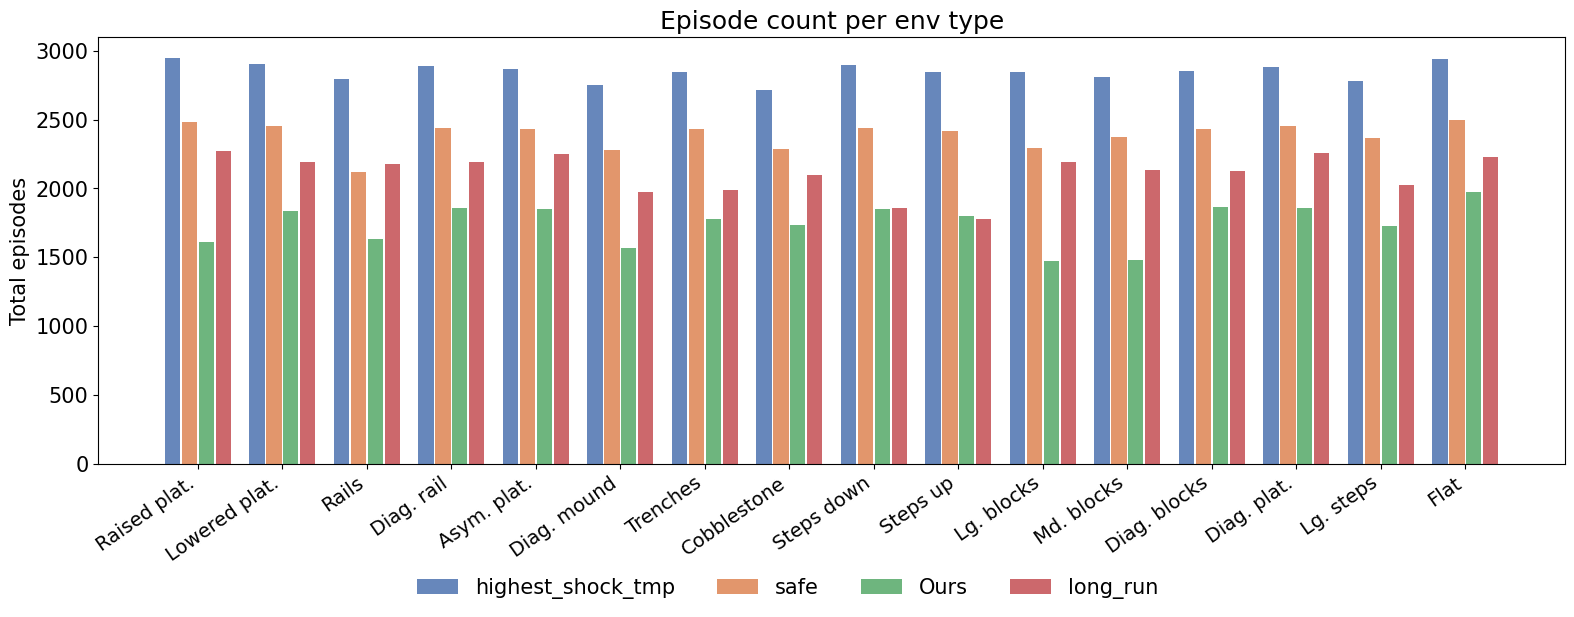

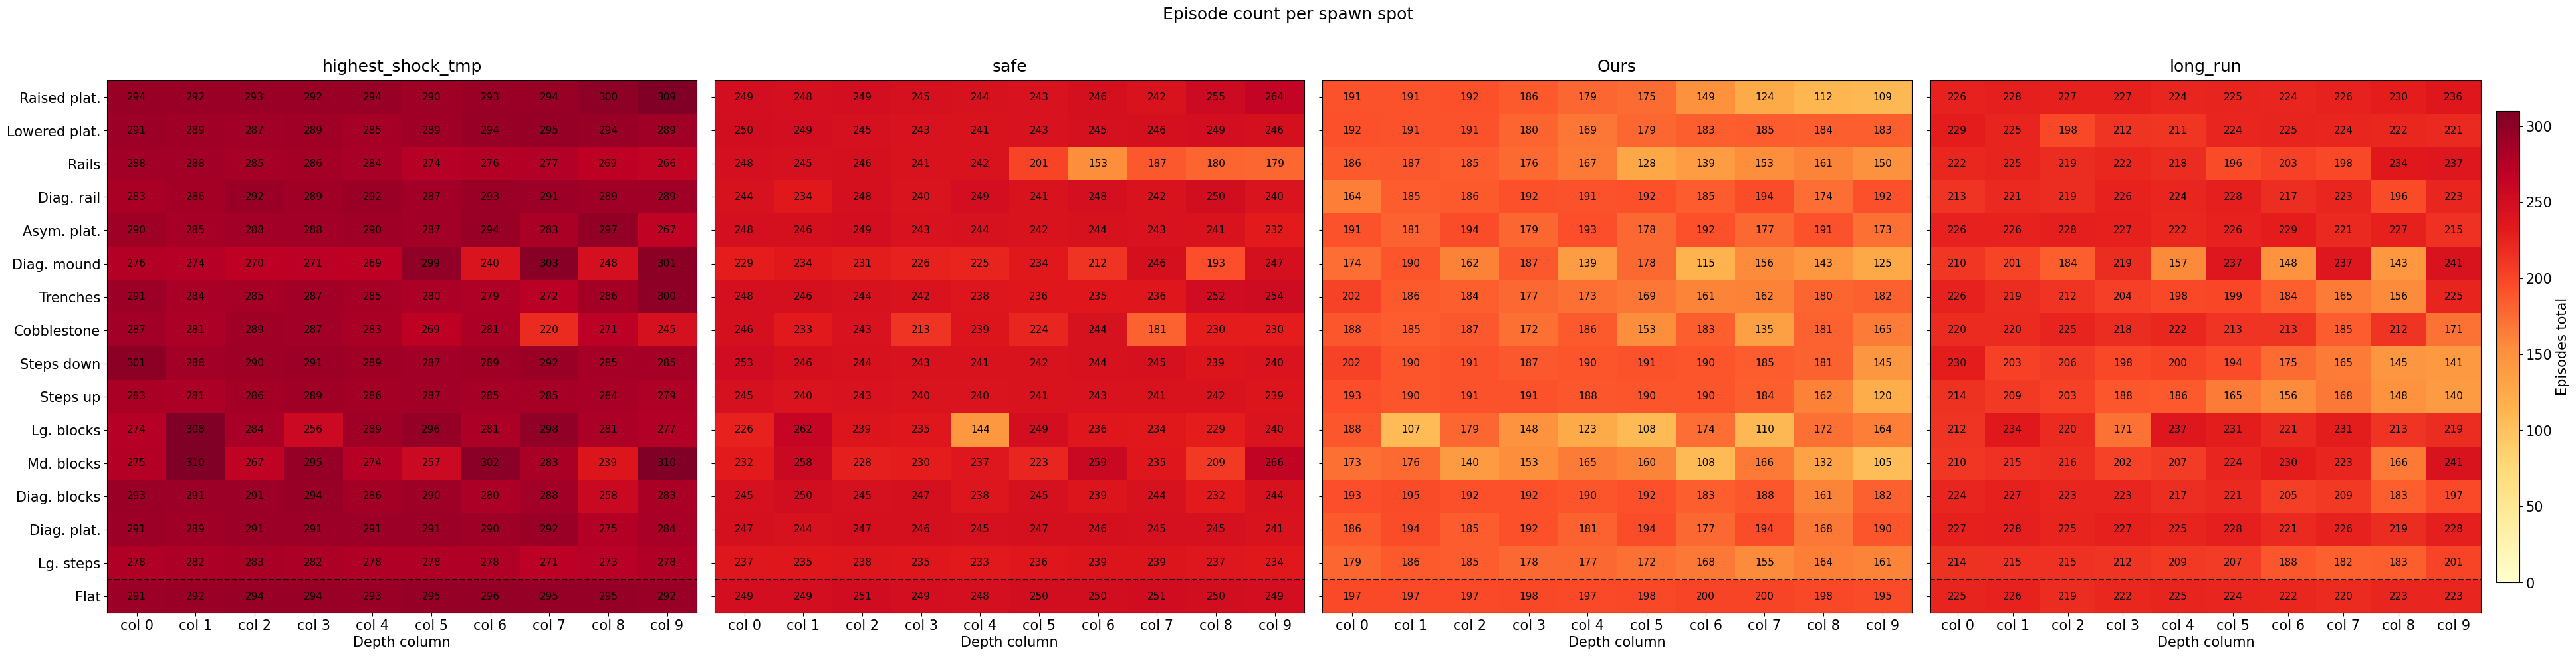

In [25]:
# ── Per-env-type episode count (bar chart) ────────────────────────────────────
env_order = sorted(per_env_df["env_type_idx"].unique())
env_name_map = per_env_df.drop_duplicates("env_type_idx").set_index("env_type_idx")["env_type_name"].to_dict()
x = np.arange(len(env_order))
n_evals = len(EVAL_ORDER)
width = 0.8 / max(n_evals, 1)

fig, ax = plt.subplots(figsize=(max(14, len(env_order)), 6))
handles, labels_legend = [], []
for ei, eid in enumerate(EVAL_ORDER):
    lbl = EVAL_LABELS.get(eid, eid)
    sub = per_env_df[per_env_df.eval_id == eid].groupby("env_type_idx")["episodes_total"].sum()
    vals = [sub.get(idx, 0) for idx in env_order]
    offset = (ei - n_evals / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width=width * 0.9,
                  color=LABEL_COLOR[lbl], alpha=0.85, label=lbl)
    handles.append(bars)
    labels_legend.append(lbl)

ax.set_xticks(x)
ax.set_xticklabels([env_short(env_name_map.get(i, str(i))) for i in env_order], rotation=35, ha="right")
ax.set_ylabel("Total episodes")
ax.set_title("Episode count per env type")
fig.legend(handles, labels_legend, loc="lower center",
           ncol=n_evals, bbox_to_anchor=(0.5, -0.05), frameon=False)
plt.tight_layout()
plt.show()

# ── Per-spot episode count heatmaps ──────────────────────────────────────────
if per_spot_df is not None:
    spot_eids = [eid for eid in EVAL_ORDER if eid in per_spot_df["eval_id"].unique()]

    def _episode_grid(df, eid):
        agg = df[df.eval_id == eid].groupby(["env_type_idx", "depth_col"])["episodes_total"].sum()
        grid = np.full((NUM_ENV_TYPES, NUM_DEPTH_COLS), np.nan)
        for (env_idx, col), val in agg.items():
            if env_idx < NUM_ENV_TYPES and col < NUM_DEPTH_COLS:
                grid[env_idx, col] = val
        return grid

    grids = {eid: _episode_grid(per_spot_df, eid) for eid in spot_eids}
    vmax = max(np.nanmax(g) for g in grids.values()) if grids else 1

    n_plots = len(spot_eids)
    fig_w = NUM_DEPTH_COLS * 0.9 * n_plots + 3
    fig_h = NUM_ENV_TYPES * 0.55 + 1
    fig, axes = plt.subplots(1, n_plots, figsize=(fig_w, fig_h),
                             squeeze=False)

    im = None
    for i, eid in enumerate(spot_eids):
        ax = axes[0, i]
        lbl = EVAL_LABELS.get(eid, eid)
        grid = grids[eid]
        im = ax.imshow(grid, aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax, interpolation="nearest")
        ax.set_yticks(range(NUM_ENV_TYPES))
        ax.set_yticklabels(ENV_NAMES if i == 0 else [], fontsize=15)
        ax.set_xticks(range(NUM_DEPTH_COLS))
        ax.set_xticklabels([f"col {c}" for c in range(NUM_DEPTH_COLS)], fontsize=15)
        ax.set_xlabel("Depth column", fontsize=15)
        ax.set_title(lbl, pad=10, fontsize=18)
        ax.axhline(14.5, color="black", linewidth=1.5, linestyle="--")
        for ei in range(NUM_ENV_TYPES):
            for c in range(NUM_DEPTH_COLS):
                val = grid[ei, c]
                if not np.isnan(val):
                    ax.text(c, ei, f"{int(val)}", ha="center", va="center", fontsize=11, color="black")

    if im is not None:
        cbar = fig.colorbar(im, ax=axes[0, -1], fraction=0.04, pad=0.025)
        cbar.ax.tick_params(labelsize=15)
        cbar.set_label("Episodes total", size=15)

    fig.suptitle("Episode count per spawn spot", fontsize=18, y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Delta episode count (only when exactly 2 evals) ──────────────────────
    if len(spot_eids) == 2:
        eid0, eid1 = spot_eids
        lbl0 = EVAL_LABELS.get(eid0, eid0)
        lbl1 = EVAL_LABELS.get(eid1, eid1)
        delta_ep = grids[eid1] - grids[eid0]
        abs_max = np.nanmax(np.abs(delta_ep))

        fig_w = NUM_DEPTH_COLS * 0.9 + 3
        fig_h = NUM_ENV_TYPES * 0.55 + 1
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
        im = ax.imshow(delta_ep, aspect="auto", cmap="RdYlGn",
                       vmin=-abs_max, vmax=abs_max, interpolation="nearest")
        ax.set_yticks(range(NUM_ENV_TYPES))
        ax.set_yticklabels(ENV_NAMES, fontsize=15)
        ax.set_xticks(range(NUM_DEPTH_COLS))
        ax.set_xticklabels([f"col {c}" for c in range(NUM_DEPTH_COLS)], fontsize=15)
        ax.set_xlabel("Depth column", fontsize=15)
        ax.set_title(f"Δ episodes  ({lbl1} − {lbl0})", pad=10, fontsize=18)
        ax.axhline(14.5, color="black", linewidth=1.5, linestyle="--")
        for ei in range(NUM_ENV_TYPES):
            for c in range(NUM_DEPTH_COLS):
                val = delta_ep[ei, c]
                if not np.isnan(val):
                    ax.text(c, ei, f"{int(val):+d}", ha="center", va="center", fontsize=11, color="black")
        cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.025)
        cbar.ax.tick_params(labelsize=15)
        cbar.set_label("Δ Episodes", size=15)
        plt.tight_layout()
        plt.show()
else:
    print("No eval_per_spot.csv found — episode count heatmaps unavailable.")

## 8  Episode distributions — step-count histogram & dist-to-goal CDF at failure

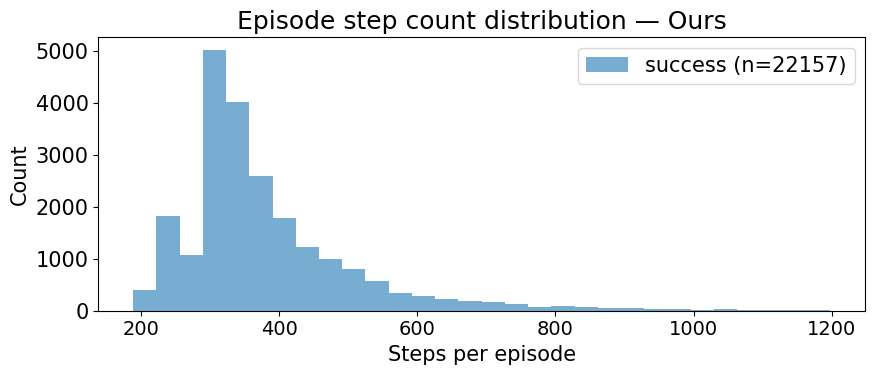

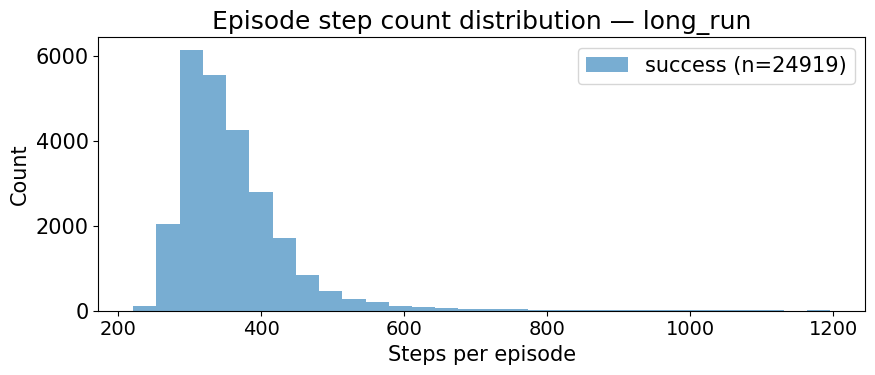

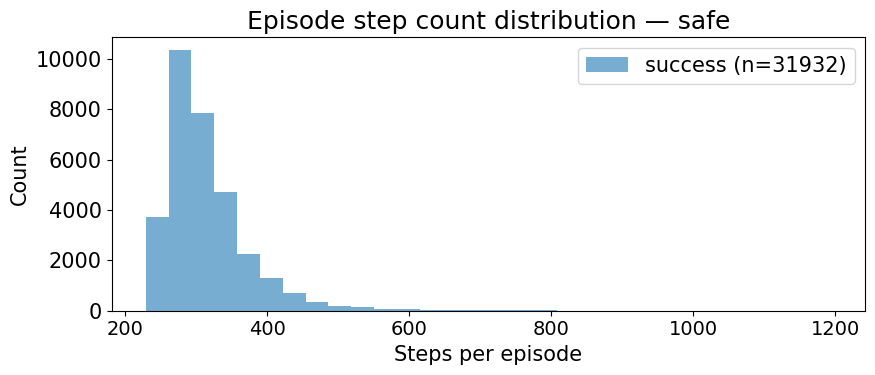

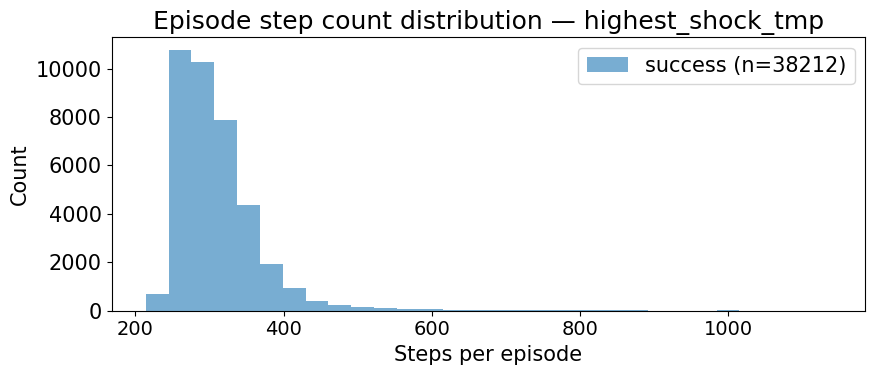

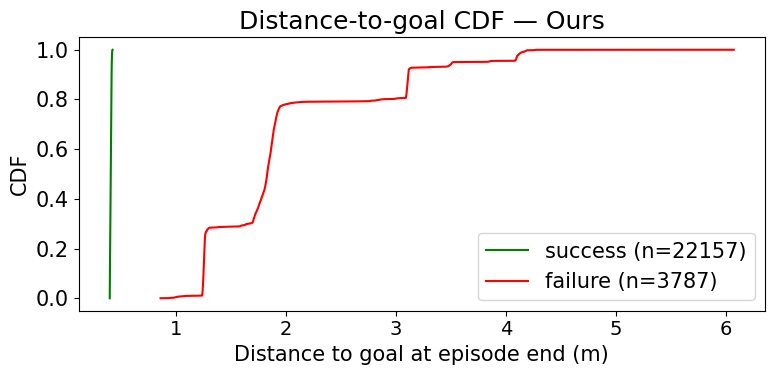

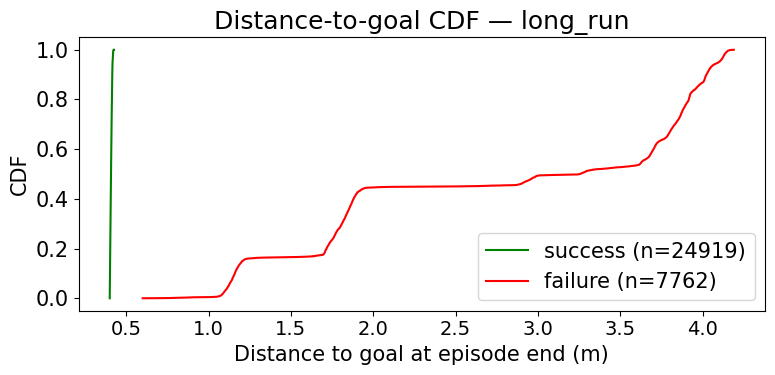

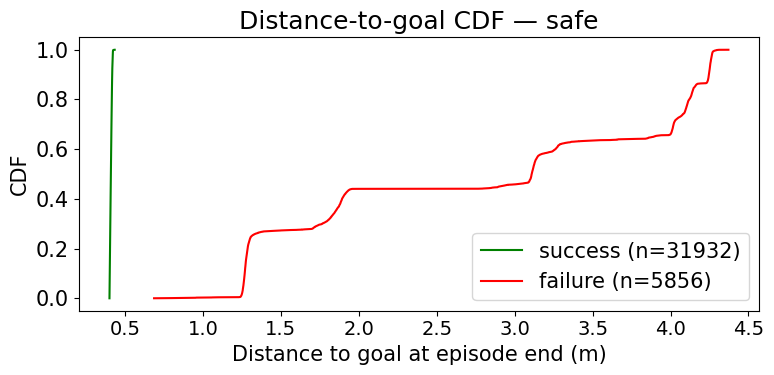

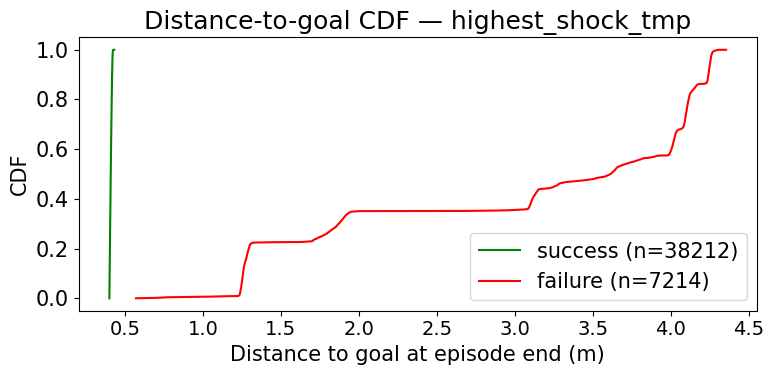

In [26]:
# Step-count histogram per outcome
for eid in eval_ids:
    lbl = EVAL_LABELS.get(eid, eid)
    sub = episodes_df[episodes_df.eval_id == eid]
    outcomes = sub["outcome"].unique()
    fig, ax = plt.subplots(figsize=(9, 4))
    for outcome in ["success"]:
        vals = sub[sub.outcome == outcome]["steps"].values
        if len(vals) > 0:
            ax.hist(vals, bins=30, alpha=0.6, label=f"{outcome} (n={len(vals)})")
    ax.set_xlabel("Steps per episode")
    ax.set_ylabel("Count")
    ax.set_title(f"Episode step count distribution — {lbl}")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Distance-to-goal CDF at episode end, split by outcome
for eid in eval_ids:
    lbl = EVAL_LABELS.get(eid, eid)
    sub = episodes_df[episodes_df.eval_id == eid]
    fig, ax = plt.subplots(figsize=(8, 4))
    for outcome, color in [("success", "green"), ("failure", "red"), ("explosion", "orange")]:
        vals = np.sort(sub[sub.outcome == outcome]["dist_to_goal_final"].dropna().values)
        if len(vals) > 0:
            cdf = np.arange(1, len(vals)+1) / len(vals)
            ax.plot(vals, cdf, label=f"{outcome} (n={len(vals)})", color=color)
    ax.set_xlabel("Distance to goal at episode end (m)")
    ax.set_ylabel("CDF")
    ax.set_title(f"Distance-to-goal CDF — {lbl}")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 9  Multi-eval comparison — side-by-side success rate

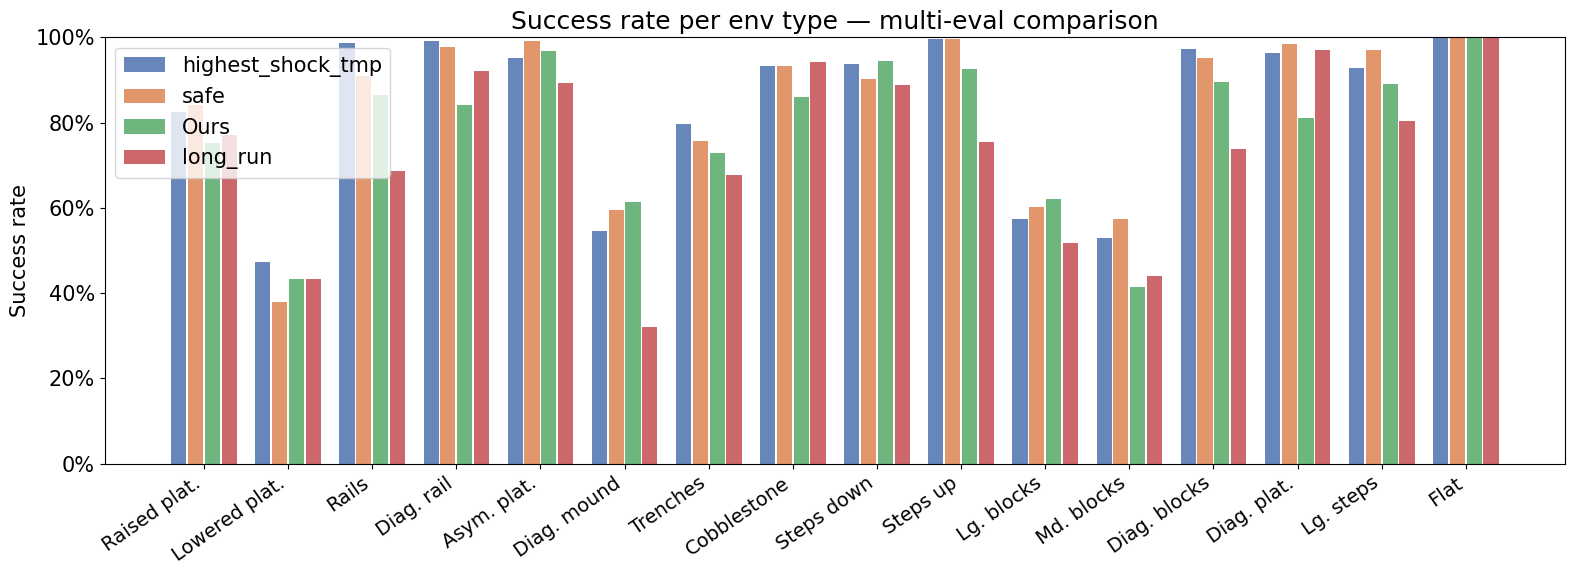

In [27]:
if len(eval_ids) < 2:
    print("Only one eval loaded — add more dirs to EVAL_DIRS or more runs to the same dir.")
else:
    env_order = sorted(per_env_df["env_type_idx"].unique())
    env_name_map = per_env_df.drop_duplicates("env_type_idx").set_index("env_type_idx")["env_type_name"].to_dict()
    x = np.arange(len(env_order))
    n_evals = len(EVAL_ORDER)
    width = 0.8 / n_evals

    fig, ax = plt.subplots(figsize=(max(12, len(env_order)), 6))
    for ei, eid in enumerate(EVAL_ORDER):
        lbl = EVAL_LABELS.get(eid, eid)
        sub = per_env_df[per_env_df.eval_id == eid].groupby("env_type_idx")["success_rate"].mean()
        vals = [sub.get(idx, np.nan) for idx in env_order]
        offset = (ei - n_evals / 2 + 0.5) * width
        ax.bar(x + offset, vals, width=width * 0.9,
               color=LABEL_COLOR[lbl], alpha=0.85, label=lbl)

    ax.set_xticks(x)
    ax.set_xticklabels([env_short(env_name_map.get(i, str(i))) for i in env_order], rotation=35, ha="right")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title("Success rate per env type — multi-eval comparison")
    ax.set_ylabel("Success rate")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Difference heatmap (eval[1] - eval[0] per env type, using EVAL_ORDER)
    if n_evals == 2:
        sr0 = per_env_df[per_env_df.eval_id == EVAL_ORDER[0]].groupby("env_type_idx")["success_rate"].mean()
        sr1 = per_env_df[per_env_df.eval_id == EVAL_ORDER[1]].groupby("env_type_idx")["success_rate"].mean()
        diff = np.array([sr1.get(i, np.nan) - sr0.get(i, np.nan) for i in env_order])
        lbl0 = EVAL_LABELS.get(EVAL_ORDER[0], EVAL_ORDER[0])
        lbl1 = EVAL_LABELS.get(EVAL_ORDER[1], EVAL_ORDER[1])

        fig, ax = plt.subplots(figsize=(max(12, len(env_order)), 4))
        im = ax.imshow([diff], aspect="auto", cmap="RdYlGn", vmin=-1, vmax=1)
        ax.set_xticks(range(len(env_order)))
        ax.set_xticklabels([env_short(env_name_map.get(i, str(i))) for i in env_order], rotation=35, ha="right")
        ax.set_yticks([])
        for j, v in enumerate(diff):
            if not np.isnan(v):
                ax.text(j, 0, f"{v:+.1%}", ha="center", va="center", fontsize=13)
        ax.set_title(f"Δ success rate  ({lbl1} − {lbl0})")
        plt.colorbar(im, ax=ax, fraction=0.05)
        plt.tight_layout()
        plt.show()

## 10  Policy vs. Random comparison

In [28]:
# This cell assumes you have at least one trained-policy eval and one random eval
# in the loaded data (they differ by policy column = "random").

policy_evals = per_env_df[per_env_df["policy"] != "random"]["eval_id"].unique().tolist()
random_evals = per_env_df[per_env_df["policy"] == "random"]["eval_id"].unique().tolist()
print(policy_evals,random_evals)
if not policy_evals or not random_evals:
    print("Need at least one trained-policy eval and one random eval in EVAL_DIRS.")
else:
    env_order = sorted(per_env_df["env_type_idx"].unique())
    env_name_map = per_env_df.drop_duplicates("env_type_idx").set_index("env_type_idx")["env_type_name"].to_dict()
    x = np.arange(len(env_order))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(12, len(env_order)), 5))
    for eids, color, label in [
        (policy_evals, PALETTE[0], "Trained policy"),
        (random_evals, PALETTE[1], "Random"),
    ]:
        sub = per_env_df[per_env_df.eval_id.isin(eids)].groupby("env_type_idx")["success_rate"].mean()
        vals = [sub.get(idx, np.nan) for idx in env_order]
        offset = -width/2 if label == "Trained policy" else width/2
        ax.bar(x + offset, vals, width=width * 0.9,
               color=color, alpha=0.85, label=label)

    ax.set_xticks(x)
    ax.set_xticklabels([env_short(env_name_map.get(i, str(i))) for i in env_order], rotation=35, ha="right")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title("Policy vs. Random — success rate per env type")
    ax.legend()
    plt.tight_layout()
    plt.show()

['best_long', 'long_run', 'safe', 'highest_shock_tmp'] []
Need at least one trained-policy eval and one random eval in EVAL_DIRS.
